# Comparing Performance Patterns in Tested vs. Untested Powerlifting Competition Entries

**Jeff Wu | ICS 604: Applied Data Science | Spring 2026 | University of Hawaii at Manoa**

---

## Introduction  

This study examines whether powerlifting competition contexts differ in performance depending on whether the entry was for a drug-tested category or a non-tested category. Using the OpenPowerlifting public dataset (~3.8 million records), the analysis compares `TotalKg` and `Dots`, looks at how tested-entry share changes across performance levels, and tracks the tested-vs-untested gap across age bins.

The cleaned base dataset remains entry-level because each row in OpenPowerlifting is one competition result. For the formal research-question analyses, I remove lifters who appear in both tested and non-tested contexts and collapse repeated same-status entries to one representative lifter row within each comparison group. That keeps the data preparation transparent while making the formal comparisons more defensible.


## Analysis Decisions

The following decisions govern the data filtering, grouping, and analysis parameters used throughout this notebook. They are collected here so the later code cells can follow one explicit analysis policy from start to finish.  

| | Decision | Value | Rationale |
|---|---|---|---|
| **Data Source** | Source file | `data/openpowerlifting-2026-03-14-dfb517af.csv` | A saved snapshot of the full OpenPowerlifting database so anyone can re-run this analysis and get the same results |
| **Data Source** | Download date | March 14, 2026 | |
| **Data Source** | Revision | `dfb517af` | |
| **Scope and Filtering** | Raw unit of analysis | One competition entry | Each row is one lifter's result from one competition |
| **Scope and Filtering** | Tested mapping | `"Yes"` marks tested; blank marks non-tested | Follows how OpenPowerlifting records whether a competition was drug-tested |
| **Scope and Filtering** | Open division allowlist | `Open` only | Focuses on the main adult division with no age or experience restrictions |
| **Scope and Filtering** | Adult rule | Keep `Age >= 18`; if `Age` is missing, drop only `AgeClass` values `5-12`, `13-15`, `16-17` | Removes anyone clearly under 18 but keeps older lifters whose exact age is unknown |
| **Scope and Filtering** | Equipment keep list | `Raw`, `Wraps`, `Single-ply`, `Multi-ply` | Keeps only the four standard equipment categories and drops rare or unclear labels |
| **Scope and Filtering** | Placement denylist | `DQ`, `DD`, `NS` | Drops entries where the lifter was disqualified, caught doping, or did not show up |
| **Scope and Filtering** | Event keep rule | `SBD` | Only includes entries where the lifter performed all three lifts (squat, bench, deadlift) |
| **Scope and Filtering** | Valid total rule | `TotalKg` must be present | Every research question needs a valid competition total to work with |
| **Scope and Filtering** | Crossover-lifter rule | Drop any lifter that appears in both tested and non-tested meets | If someone competed in both tested and non-tested meets, they are removed so each lifter belongs to only one group |
| **Formal Analysis Units** | RQ1 formal unit | One representative row per lifter, sex, equipment, weight class, and tested status | If a lifter competed multiple times in the same weight class and equipment, their results are averaged into one row |
| **Formal Analysis Units** | RQ2 formal unit | One representative row per lifter, sex, and tested status | Each lifter contributes one average DOTS score so frequent competitors do not count extra |
| **Formal Analysis Units** | RQ3 formal unit | One representative row per lifter, sex, age bin, and tested status (among rows with known age) | If a lifter competed multiple times in the same age range, their results are averaged into one row |
| **Formal Analysis Units** | Repeat-entry rule | Collapse repeated same-status entries with the mean | Averaging is the simplest way to combine multiple competition results into one |
| **Analysis Parameters** | Minimum subgroup count | `30` | Any group with fewer than 30 lifters is too small for reliable comparison and is excluded |
| **Analysis Parameters** | RQ1 metrics | `TotalKg`, `Dots` | TotalKg compares lifters in the same weight class; DOTS adjusts for body weight so different classes can be compared |
| **Analysis Parameters** | RQ2 binning rule | `5` equal-width DOTS bins within sex | Five bins gives enough groups to see a pattern while keeping each bin large enough for the chi-squared test to be valid |
| **Analysis Parameters** | RQ3 age bins | `18-23`, `24-30`, `31-40`, `41-50`, `51-60`, `61+` | Older age groups are wider because fewer lifters compete at those ages |
| **Analysis Parameters** | RQ3 boundary-age rule | Ages on a bin edge go into the younger bin | An age like 23.5 is placed in the 18-23 bin rather than 24-30, and this rule is applied consistently |
| **Interpretation** | Interpretation rule | No causal PED claims | A "tested" label only means the competition had drug testing; it does not prove a lifter is drug-free or was actually tested |

## Imports and Configuration  

Load the libraries used throughout the analysis and set display and plotting defaults.

In [59]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:0.4f}".format)

plt.style.use("ggplot")
np.random.seed(604)

DATA_PATH = "data/openpowerlifting-2026-03-14-dfb517af.csv"

## Data Loading  

The analysis uses the OpenPowerlifting dataset, a community-maintained, publicly available archive of competitive powerlifting results. OpenPowerlifting aggregates official competition records from hundreds of national and international federations, standardizes them into a single flat-file format, and releases the data under a Creative Commons Zero (CC0) license. The revision of the dataset used in this analysis contains over 3.8 million individual competition entries spanning decades of meets across dozens of countries. 

Each row represents one competition entry which is a single lifter's results for a single meet. It includes demographic fields (sex, age, bodyweight, weight class), performance fields (best squat, bench press, deadlift, and total in kilograms), contextual fields (federation, equipment category, meet date, and country), and standardized scoring fields such as DOTS. Critical to this study, the dataset includes a `Tested` field that indicates whether the entry was recorded under a drug-tested or untested competition context.  

**Snapshot used:** Revision `dfb517af`, retrieved March 14, 2026, from the OpenPowerlifting bulk CSV distribution. Pinning the analysis to a specific revision ensures that all results reported in this notebook are fully reproducible against the same underlying data.

**Download the dataset from Github** and extract the zip file contents to `data/`.  

https://github.com/wuj/ics604-final-project/releases/download/v1.0.0/openpowerlifting-2026-03-14.zip


The cell below loads the raw CSV and confirms the expected shape and columns before anything else is done.

In [60]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError( 
        f"Expected dataset '{os.path.basename(DATA_PATH)}' not found at: {DATA_PATH}\n"
        "Download it from:\n"
        "  https://github.com/wuj/ics604-final-project/releases/download/v1.0.0/openpowerlifting-2026-03-14.zip\n"
        "Then unzip and place the CSV in the data/ directory."
    )

raw_df = pd.read_csv(DATA_PATH, low_memory=False)

print("Data shape:", raw_df.shape)

print("")
print("Columns")
display(raw_df.dtypes.to_frame("dtype"))

print("")
print("Preview:")
display(raw_df.head())

Data shape: (3868570, 42)

Columns


,dtype
Name,str
Sex,str
Event,str
Equipment,str
Age,float64
AgeClass,str
BirthYearClass,str
Division,str
BodyweightKg,float64
WeightClassKg,str



Preview:


,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Glossbrenner,Goodlift,Tested,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName,Sanctioned
0,E.S. Denisenko,F,B,Raw,28.5000,24-34,24-39,Open,67.3000,NaN,NaN,NaN,NaN,NaN,NaN,-40.0000,-45.0000,-45.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
1,I.S. Lebetskaya,F,B,Raw,43.5000,40-44,40-49,Open,73.2000,NaN,NaN,NaN,NaN,NaN,NaN,80.0000,85.0000,90.0000,NaN,90.0000,NaN,NaN,NaN,NaN,NaN,90.0000,1,88.8000,86.8900,76.5000,70.0600,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
2,K. Yakimovich,F,B,Raw,26.5000,24-34,24-39,Open,60.6000,NaN,NaN,NaN,NaN,NaN,NaN,40.0000,42.5000,45.0000,NaN,45.0000,NaN,NaN,NaN,NaN,NaN,45.0000,2,49.5700,49.7900,43.9800,38.4200,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
3,A.G. Golneva,F,B,Raw,19.5000,20-23,19-23,Juniors 17-21,50.3000,NaN,NaN,NaN,NaN,NaN,NaN,32.5000,35.0000,-37.5000,NaN,35.0000,NaN,NaN,NaN,NaN,NaN,35.0000,2,43.6700,44.7600,39.7300,34.5500,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
4,E.V. Marunevskaya,F,B,Raw,19.5000,20-23,19-23,Juniors 17-21,63.7000,NaN,NaN,NaN,NaN,NaN,NaN,40.0000,42.5000,-45.0000,NaN,42.5000,NaN,NaN,NaN,NaN,NaN,42.5000,1,45.4000,45.2600,39.9600,35.2500,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes


## Data Inspection

Before any filtering or transformation, it is important to understand the raw values in the columns that will drive the analysis. The OpenPowerlifting dataset aggregates records from hundreds of federations, each with its own labeling conventions, so fields like `Tested`, `Division`, and `Equipment` may contain inconsistent or unexpected values that could silently bias the analysis subset if taken at face value.

This cell examines:

- **`Tested` labels** -- the field central to every research question. The raw values must be reviewed to confirm that the tested/untested mapping is unambiguous before it is applied downstream.
- **`Division` labels** -- competition divisions vary widely across federations. Only labels that clearly represent unrestricted adult Open competition should be retained, so the most frequent labels are printed here for manual review.
- **Missing values in key columns** -- columns required for the analysis are checked for null counts. High missing-value counts in any of these may constrain the usable subset or require imputation decisions.
- **Label frequencies** -- value counts for `Equipment`, `Sex`, `Event`, `Place`, and `WeightClassKg` are printed to verify that expected categories are present and to inform us of rare or malformed labels.

The findings from this cell inform the filtering rules and constant definitions applied in the Data Cleaning step that follows.

In [61]:
key_cols = [
    "Tested", "Division", "Equipment", "Sex", "Event", "Place",
    "Age", "WeightClassKg", "TotalKg", "Dots", "Date"
]

print("Number of rows that have missing values in key columns:")
print(raw_df[key_cols].isna().sum())

for col in ["Tested", "Division", "Equipment", "Sex", "Event", "Place", "WeightClassKg"]:
    print(f"\n=== {col} ===")
    print(raw_df[col].value_counts(dropna=False).head(30))

tested_raw = raw_df["Tested"].fillna("")
tested_raw = tested_raw.astype(str)
tested_raw = tested_raw.str.strip()
tested_values = tested_raw.value_counts(dropna=False)

print("")
print("Tested values:")
print(tested_values) 

Number of rows that have missing values in key columns:
Tested            926873
Division            3747
Equipment              0
Sex                    0
Event                  0
Place                  0
Age              1437073
WeightClassKg      57481
TotalKg           262757
Dots              288804
Date                   0
dtype: int64

=== Tested ===
Tested
Yes    2941697
NaN     926873
Name: count, dtype: int64

=== Division ===
Division
Open                     995018
Boys                     526100
Girls                    325102
Juniors                  135709
MR-O                     104007
Sub-Juniors               70374
Amateur Open              70329
Pro Open                  64873
FR-O                      60200
Masters 1                 57580
Juniors 20-23             43931
O                         41598
Masters 2                 41116
M-O                       39638
MR-Jr                     37502
Masters 40-44             27146
Masters 3                 21008
Master

## Data Cleaning

As noted in the Data Inspection step, several columns contain inconsistent types, missing values (especially in older meets), and categorical labels that must be standardized before analysis. Building on the data preparation workflow from class, the steps below define the cleaned base dataset that all later research-question cells will start from:

- **Full-power only:** `Event == "SBD"`
- **Exclude non-valid placements:**  
  - `DQ` - Disqualified  
  - `DD` - Doping Disqualification  
  - `NS` - No-Show
- **Open division only:** exact `Division == "Open"`
- **Sex restricted:** `M` or `F` only
- **Standard equipment:** `Raw`, `Wraps`, `Single-ply`, `Multi-ply`
- **Valid totals:** `TotalKg` must be present
- **Determinable tested status:** `Tested` is either `"Yes"` or blank
- **Adult rule:** keep `Age >= 18`; if `Age` is missing, drop only rows whose `AgeClass` clearly marks a minor (`5-12`, `13-15`, `16-17`)
- **Crossover-lifter rule:** after `is_tested` is created, drop any `Name` that appears in both tested and non-tested contexts


In [62]:
DIVISION_ALLOWLIST = ["Open"]
EQUIPMENT_ALLOWLIST = ["Raw", "Wraps", "Single-ply", "Multi-ply"]
PLACEMENT_DENYLIST = ["DQ", "DD", "NS"]
DEFINITE_MINOR_AGECLASSES = ["5-12", "13-15", "16-17"]
BOUNDARY_HALF_AGES = [23.5, 30.5, 40.5, 50.5, 60.5]

df = raw_df.copy()

for col in [
    "Name", "Tested", "Division", "Equipment", "Sex", "Event",
    "Place", "WeightClassKg", "AgeClass", "BirthYearClass"
]:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for col in ["Age", "TotalKg", "Dots"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["Event"] == "SBD"]
df = df[~df["Place"].isin(PLACEMENT_DENYLIST)]
df = df[df["Division"].isin(DIVISION_ALLOWLIST)]
df = df[df["Sex"].isin(["M", "F"])]
df = df[df["Equipment"].isin(EQUIPMENT_ALLOWLIST)]
df = df[df["TotalKg"].notna()]
df = df[df["Tested"].isin(["", "Yes"])].copy()

known_minor_mask = df["Age"] < 18
missing_age_minor_mask = (
    df["Age"].isna() &
    df["AgeClass"].isin(DEFINITE_MINOR_AGECLASSES)
)

df = df[~(known_minor_mask | missing_age_minor_mask)].copy()

df["is_tested"] = df["Tested"].eq("Yes")

status_counts = df.groupby("Name")["is_tested"].nunique()
crossover_names = status_counts[status_counts > 1].index
crossover_removed = df["Name"].isin(crossover_names).sum()
df = df[~df["Name"].isin(crossover_names)].copy()

df.loc[df["WeightClassKg"] == "", "WeightClassKg"] = np.nan
boundary_age_count = df["Age"].isin(BOUNDARY_HALF_AGES).sum()

print("Rows removed because Age < 18:", f"{known_minor_mask.sum():,}")
print("Rows removed because missing AgeClass showed a definite minor:", f"{missing_age_minor_mask.sum():,}")
print("Rows removed from crossover lifters:", f"{crossover_removed:,}")
print("Boundary .5 ages kept for the lower-bin convention:", f"{boundary_age_count:,}")

print("")
print("Tested split:")
display(df["is_tested"].value_counts(dropna=False).to_frame("count"))

print("")
print("Final cleaned subset shape:")
print(df.shape)

print("")
df.to_csv("data/powerlifting-clean.csv", index=False)
print("Saved to data/powerlifting-clean.csv")


Rows removed because Age < 18: 27,587
Rows removed because missing AgeClass showed a definite minor: 1,185
Rows removed from crossover lifters: 99,660
Boundary .5 ages kept for the lower-bin convention: 23,077

Tested split:


,count
is_tested,
True,345679
False,165203



Final cleaned subset shape:
(510882, 43)

Saved to data/powerlifting-clean.csv


## Base State Setup

Before moving on to the research questions, this section loads the corrected base dataset, sets the shared constants, and builds the representative lifter-level analysis tables used later in the notebook. I keep those tables separate from the cleaned base data.


In [63]:
df = pd.read_csv("data/powerlifting-clean.csv", low_memory=False)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in ["Age", "TotalKg", "Dots"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

ALPHA = 0.05
MIN_COUNT = 30
N_RQ2_BINS = 5
N_PERMUTATIONS = 10_000
N_BOOTSTRAP = 10_000

AGE_BINS = [18, 24, 31, 41, 51, 61, np.inf]
AGE_LABELS = ["18-23", "24-30", "31-40", "41-50", "51-60", "61+"]
BOUNDARY_HALF_AGES = [23.5, 30.5, 40.5, 50.5, 60.5]

df["age_bin"] = pd.cut(
    df["Age"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False
)

rq1_base_df = (
    df.dropna(subset=["WeightClassKg", "TotalKg", "Dots"])
    .groupby(["Name", "Sex", "Equipment", "WeightClassKg", "is_tested"], as_index=False)
    .agg(
        TotalKg=("TotalKg", "mean"),
        Dots=("Dots", "mean")
    )
)

rq2_base_df = (
    df.dropna(subset=["Dots"])
    .groupby(["Name", "Sex", "is_tested"], as_index=False)
    .agg(Dots=("Dots", "mean"))
)

rq3_base_df = (
    df.dropna(subset=["age_bin", "TotalKg"])
    .groupby(["Name", "Sex", "age_bin", "is_tested"], as_index=False)
    .agg(TotalKg=("TotalKg", "mean"))
)

dots_missing_pct = df["Dots"].isna().mean() * 100
age_missing_pct = df["Age"].isna().mean() * 100
weightclass_missing_pct = df["WeightClassKg"].isna().mean() * 100
boundary_age_count = df["Age"].isin(BOUNDARY_HALF_AGES).sum()

print(f"Rows in cleaned dataset: {len(df):,}")

print("")
print(f"DOTS missing: {dots_missing_pct:.1f}%")
print(f"Age missing: {age_missing_pct:.1f}%")
print(f"WeightClassKg missing: {weightclass_missing_pct:.1f}%")
print(f"Boundary .5 ages kept in the lower bin: {boundary_age_count:,}")

print("")
print("Age-bin preview:")

display(df[["Age", "age_bin", "TotalKg", "Dots"]].head())


Rows in cleaned dataset: 510,882

DOTS missing: 0.9%
Age missing: 28.7%
WeightClassKg missing: 0.9%
Boundary .5 ages kept in the lower bin: 23,077

Age-bin preview:


,Age,age_bin,TotalKg,Dots
0,30.0000,24-30,202.5000,271.4400
1,29.0000,24-30,247.5000,293.2300
2,28.0000,24-30,250.0000,269.1400
3,23.5000,18-23,495.0000,368.9200
4,25.0000,24-30,597.5000,410.5000


## Analysis Coverage Checks

Before proceeding to the research questions, this section checks whether the representative lifter-level analysis tables support the planned comparisons.

1. **RQ1 subgroup support:** RQ1 uses one representative row per `Name x Sex x Equipment x WeightClassKg x is_tested`. Each `Sex x Equipment x WeightClassKg` subgroup still needs enough tested and non-tested lifters on both sides of the comparison.
2. **RQ2 expected counts:** RQ2 uses one representative row per `Name x Sex x is_tested`, then builds 5 equal-width `Dots` bins within sex. The chi-squared test still needs expected counts of at least 5 in every active cell.
3. **RQ3 age-bin coverage:** RQ3 uses one representative row per `Name x Sex x age_bin x is_tested` among rows with known age / assigned age bin. Each `Sex x age_bin` cell still needs enough tested and non-tested representative rows for the bootstrap gap comparison.

The supported subgroup tables created here are the ones used in the formal analysis cells below.


In [64]:
# RQ1 support: representative lifter-status rows inside each subgroup.

rq1_counts = (
    rq1_base_df
    .groupby(["Sex", "Equipment", "WeightClassKg", "is_tested"])
    .size()
    .reset_index(name="n")
)

rq1_tested = (
    rq1_counts[rq1_counts["is_tested"] == True]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_tested"})
)

rq1_untested = (
    rq1_counts[rq1_counts["is_tested"] == False]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_untested"})
)

rq1_pairs = pd.merge(
    rq1_tested,
    rq1_untested,
    on=["Sex", "Equipment", "WeightClassKg"],
    how="inner"
)

rq1_supported_keys = rq1_pairs[
    (rq1_pairs["n_tested"] >= MIN_COUNT) &
    (rq1_pairs["n_untested"] >= MIN_COUNT)
].copy()

rq1_supported_df = pd.merge(
    rq1_base_df,
    rq1_supported_keys[["Sex", "Equipment", "WeightClassKg"]].drop_duplicates(),
    on=["Sex", "Equipment", "WeightClassKg"],
    how="inner"
)

print("RQ1 representative rows with WeightClassKg, TotalKg, and Dots:", f"{len(rq1_base_df):,}")
print("RQ1 subgroup pairs with both tested and non-tested rows:", len(rq1_pairs))
print(f"RQ1 subgroup pairs meeting MIN_COUNT={MIN_COUNT}:", len(rq1_supported_keys))

# RQ2 support: keep all representative rows, then check expected counts.

rq2_analysis_df = rq2_base_df.copy()

print("\nRQ2 representative rows:", f"{len(rq2_analysis_df):,}")

for sex in ["M", "F"]:
    sex_df = rq2_analysis_df[rq2_analysis_df["Sex"] == sex].copy()

    bin_edges = np.linspace(
        sex_df["Dots"].min(),
        sex_df["Dots"].max(),
        N_RQ2_BINS + 1
    )

    sex_df["dots_bin"] = pd.cut(
        sex_df["Dots"],
        bins=bin_edges,
        include_lowest=True
    )

    # Count rows in each (dots_bin, is_tested) group, then pivot so
    # each tested status becomes its own column. fill_value=0 means
    # any bin with no rows for a status gets a zero instead of NaN.
    contingency = (
        sex_df.groupby(["dots_bin", "is_tested"])
        .size()
        .unstack(fill_value=0)
    )
    # If a column is missing, add it with zeros so both columns always exist.
    if True not in contingency.columns:
        contingency[True] = 0
    if False not in contingency.columns:
        contingency[False] = 0
    contingency = contingency[contingency.sum(axis=1) > 0]

    _, _, _, expected = stats.chi2_contingency(contingency)

    print(f"\nRQ2 support for sex={sex}")
    print(f"  active bins: {len(contingency)}")
    print(f"  all expected counts >= 5: {(expected >= 5).all()}")
    print(f"  minimum expected count: {expected.min():.2f}")

# RQ3 support: representative lifter-status rows inside each sex x age_bin cell.

rq3_counts = (
    rq3_base_df
    .groupby(["Sex", "age_bin", "is_tested"])
    .size()
    .reset_index(name="n")
)

rq3_tested = (
    rq3_counts[rq3_counts["is_tested"] == True]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_tested"})
)

rq3_untested = (
    rq3_counts[rq3_counts["is_tested"] == False]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_untested"})
)

rq3_pairs = pd.merge(
    rq3_tested,
    rq3_untested,
    on=["Sex", "age_bin"],
    how="inner"
)

rq3_supported = rq3_pairs[
    (rq3_pairs["n_tested"] >= MIN_COUNT) &
    (rq3_pairs["n_untested"] >= MIN_COUNT)
].copy()

rq3_supported_df = pd.merge(
    rq3_base_df,
    rq3_supported[["Sex", "age_bin"]].drop_duplicates(),
    on=["Sex", "age_bin"],
    how="inner"
)

print("\nRQ3 representative rows with age_bin and TotalKg:", f"{len(rq3_base_df):,}")
print("RQ3 sex-age pairs with both tested and non-tested rows:", len(rq3_pairs))
print(f"RQ3 sex-age pairs meeting MIN_COUNT={MIN_COUNT}:", len(rq3_supported))

print("")
print("RQ3 supported cells preview:")
display(rq3_supported.sort_values(["Sex", "age_bin"]))


RQ1 representative rows with WeightClassKg, TotalKg, and Dots: 295,718
RQ1 subgroup pairs with both tested and non-tested rows: 168
RQ1 subgroup pairs meeting MIN_COUNT=30: 78

RQ2 representative rows: 225,578

RQ2 support for sex=M
  active bins: 5
  all expected counts >= 5: True
  minimum expected count: 83.46

RQ2 support for sex=F
  active bins: 5
  all expected counts >= 5: True
  minimum expected count: 7.93

RQ3 representative rows with age_bin and TotalKg: 176,349
RQ3 sex-age pairs with both tested and non-tested rows: 12
RQ3 sex-age pairs meeting MIN_COUNT=30: 12

RQ3 supported cells preview:


,Sex,age_bin,n_tested,n_untested
0,F,18-23,11045,1968
1,F,24-30,14265,7534
2,F,31-40,8508,4904
3,F,41-50,2170,1048
4,F,51-60,662,289
5,F,61+,181,84
6,M,18-23,29890,6497
7,M,24-30,32031,18599
8,M,31-40,17140,11091
9,M,41-50,4009,1903


## RQ1: Natty or Not? (Main Performance Comparison)

**Do non-tested entries tend to show higher `TotalKg` and `Dots` scores than tested entries?**

RQ1 uses one representative row per `Name x Sex x Equipment x WeightClassKg x is_tested`, where repeated same-status entries are collapsed to a mean `TotalKg` and mean `Dots` value first. Subgroups with fewer than 30 representative rows on either side are excluded so that both the bootstrap and permutation procedures have enough data to work with.

**Hypotheses:**

- **H0:** Non-tested entries do not have higher mean `Dots`/`TotalKg` than tested entries within the same subgroup.
- **Ha:** Non-tested entries have higher mean `Dots`/`TotalKg` (one-sided).

**Approach:**

For each qualifying subgroup the non-tested-minus-tested gap is assessed three ways: a 95% bootstrap CI (10,000 resamples, percentile method) for direction and size; a one-sided permutation test (10,000 shuffles) for significance; and a one-sided Welch t-test as a parametric cross-check. Both `TotalKg` and `Dots` are compared, though within a single weight class the two metrics are nearly proportional because bodyweight varies little.

In [65]:
# =============================================================================
# RQ1 Summary Table
# For each Sex x Equipment x WeightClassKg subgroup, compute the mean
# TotalKg and Dots on the tested and non-tested sides, then compute
# the raw performance gap (non-tested minus tested) for each metric.
# =============================================================================

# Build one row per subgroup/status with counts and average scores.
summary = (
    rq1_supported_df
    .groupby(["Sex", "Equipment", "WeightClassKg", "is_tested"])
    .agg(
        n=("TotalKg", "size"),
        mean_total=("TotalKg", "mean"),
        mean_dots=("Dots", "mean")
    )
    .reset_index()
)

# Keep only the tested side so it is easy to compare later.
tested = (
    summary[summary["is_tested"] == True]
    .drop(columns="is_tested")
    .rename(columns={
        "n": "n_tested",
        "mean_total": "mean_total_tested",
        "mean_dots": "mean_dots_tested"
    })
)

# Keep only the non-tested side so it lines up with the tested table.
untested = (
    summary[summary["is_tested"] == False]
    .drop(columns="is_tested")
    .rename(columns={
        "n": "n_untested",
        "mean_total": "mean_total_untested",
        "mean_dots": "mean_dots_untested"
    })
)

# Put the tested and non-tested subgroup summaries side by side.
rq1_gap_table = pd.merge(
    tested,
    untested,
    on=["Sex", "Equipment", "WeightClassKg"],
    how="inner"
)

rq1_gap_table["gap_total"] = (
    rq1_gap_table["mean_total_untested"] - rq1_gap_table["mean_total_tested"]
)
rq1_gap_table["gap_dots"] = (
    rq1_gap_table["mean_dots_untested"] - rq1_gap_table["mean_dots_tested"]
)

print(f"Qualifying RQ1 subgroup pairs at MIN_COUNT={MIN_COUNT}: {len(rq1_gap_table)}")
display(rq1_gap_table.sort_values(["Sex", "Equipment", "WeightClassKg"]).reset_index(drop=True))

Qualifying RQ1 subgroup pairs at MIN_COUNT=30: 78


,Sex,Equipment,WeightClassKg,n_tested,mean_total_tested,mean_dots_tested,n_untested,mean_total_untested,mean_dots_untested,gap_total,gap_dots
0,F,Raw,100,523,340.7065,296.5468,352,345.8113,300.2727,5.1048,3.7259
1,F,Raw,110,209,358.3553,299.1388,231,354.7993,296.5978,-3.5560,-2.5410
2,F,Raw,110+,208,367.4075,292.7958,118,371.0880,296.4365,3.6805,3.6407
3,F,Raw,44,56,211.4256,294.4768,77,208.7466,291.6809,-2.6790,-2.7959
4,F,Raw,48,229,240.7885,315.8990,230,243.4511,319.0417,2.6626,3.1427
5,F,Raw,52,2752,264.8543,327.7442,608,259.6457,321.3996,-5.2086,-6.3447
6,F,Raw,56,691,270.2071,317.5617,1039,275.6582,324.4382,5.4511,6.8765
7,F,Raw,57,3839,287.4058,334.2550,79,280.3956,327.6501,-7.0102,-6.6048
8,F,Raw,60,990,283.4787,318.2268,1629,292.4281,328.3535,8.9494,10.1266
9,F,Raw,63,5468,303.2615,331.6842,125,294.8507,324.0537,-8.4108,-7.6305


In [66]:
# =============================================================================
# RQ1 Tests
# For each subgroup, test whether non-tested entries score higher than
# tested entries using bootstrap CIs, permutation tests, and Welch's
# t-test on both TotalKg and Dots.
# =============================================================================

def test_performance_gap(tested_vals, untested_vals):
    observed_gap = untested_vals.mean() - tested_vals.mean()

    # Bootstrap confidence interval (percentile method)
    # Resample each group with replacement, recompute the gap each time,
    # then take the 2.5th and 97.5th percentiles as the 95% CI bounds.
    bootstrap_gaps = []
    for i in range(N_BOOTSTRAP):
        bootstrap_tested = np.random.choice(tested_vals, size=len(tested_vals), replace=True)
        bootstrap_untested = np.random.choice(untested_vals, size=len(untested_vals), replace=True)
        bootstrap_gaps.append(bootstrap_untested.mean() - bootstrap_tested.mean())

    bootstrap_gaps = np.array(bootstrap_gaps)
    ci_low, ci_high = np.percentile(bootstrap_gaps, [2.5, 97.5])

    # Permutation testing
    # Concatenate the two samples, shuffle the combined data, split into
    # two new groups, and recompute the gap each time. The one-sided
    # p-value is the fraction of shuffled gaps that are at least as large
    # as the observed gap.
    all_data = np.concatenate([untested_vals, tested_vals])
    n_untested = len(untested_vals)
    permutation_gaps = []
    for i in range(N_PERMUTATIONS):
        shuffled = all_data.copy()
        np.random.shuffle(shuffled)
        permutation_gaps.append(shuffled[:n_untested].mean() - shuffled[n_untested:].mean())

    permutation_gaps = np.array(permutation_gaps)
    p_perm = np.mean(permutation_gaps >= observed_gap)

    # Welch's t-test
    # Independent-samples t-test without assuming equal variances.
    # The alternative="greater" parameter is a built-in scipy option that makes
    # the test one-sided, matching Ha: mean(non-tested) > mean(tested).
    welch = stats.ttest_ind(
        untested_vals,
        tested_vals,
        equal_var=False,
        alternative="greater",
    )

    return observed_gap, ci_low, ci_high, p_perm, welch.statistic, welch.pvalue

rq1_results = []

for (sex, equipment, weight_class), group in rq1_supported_df.groupby(["Sex", "Equipment", "WeightClassKg"]):
    tested_group = group[group["is_tested"] == True]
    untested_group = group[group["is_tested"] == False]

    tested_total = tested_group["TotalKg"].dropna().values
    untested_total = untested_group["TotalKg"].dropna().values
    tested_dots = tested_group["Dots"].dropna().values
    untested_dots = untested_group["Dots"].dropna().values

    total_gap, total_lo, total_hi, total_p_perm, total_t, total_p_welch = test_performance_gap(
        tested_total,
        untested_total
    )

    dots_gap, dots_lo, dots_hi, dots_p_perm, dots_t, dots_p_welch = test_performance_gap(
        tested_dots,
        untested_dots
    )

    rq1_results.append({
        "Sex": sex,
        "Equipment": equipment,
        "WeightClassKg": weight_class,
        "n_tested": len(tested_total),
        "n_untested": len(untested_total),
        "gap_total": total_gap,
        "gap_total_ci_low": total_lo,
        "gap_total_ci_high": total_hi,
        "gap_total_perm_p": total_p_perm,
        "gap_total_welch_t": total_t,
        "gap_total_welch_p": total_p_welch,
        "gap_dots": dots_gap,
        "gap_dots_ci_low": dots_lo,
        "gap_dots_ci_high": dots_hi,
        "gap_dots_perm_p": dots_p_perm,
        "gap_dots_welch_t": dots_t,
        "gap_dots_welch_p": dots_p_welch
    })

rq1_results = pd.DataFrame(rq1_results)

print(f"RQ1 formal-test subgroups analyzed: {len(rq1_results)}")
display(rq1_results.sort_values(["Sex", "Equipment", "WeightClassKg"]).reset_index(drop=True))

RQ1 formal-test subgroups analyzed: 78


,Sex,Equipment,WeightClassKg,n_tested,n_untested,gap_total,gap_total_ci_low,gap_total_ci_high,gap_total_perm_p,gap_total_welch_t,gap_total_welch_p,gap_dots,gap_dots_ci_low,gap_dots_ci_high,gap_dots_perm_p,gap_dots_welch_t,gap_dots_welch_p
0,F,Raw,100,523,352,5.1048,-4.6965,14.7663,0.1443,1.0209,0.1538,3.7259,-4.7164,12.2735,0.1818,0.8619,0.1945
1,F,Raw,110,209,231,-3.5560,-17.0458,10.4488,0.6908,-0.5068,0.6937,-2.5410,-13.8896,8.8466,0.6640,-0.4352,0.6682
2,F,Raw,110+,208,118,3.6805,-13.3513,21.3459,0.3298,0.4165,0.3387,3.6407,-10.1734,17.5325,0.3041,0.5158,0.3032
3,F,Raw,44,56,77,-2.6790,-19.0529,13.4099,0.6267,-0.3166,0.6239,-2.7959,-25.7545,19.9033,0.5917,-0.2388,0.5942
4,F,Raw,48,229,230,2.6626,-5.5108,10.7103,0.2666,0.6363,0.2625,3.1427,-7.4197,13.7202,0.2786,0.5771,0.2821
5,F,Raw,52,2752,608,-5.2086,-9.5281,-0.8924,0.9864,-2.3883,0.9914,-6.3447,-11.6008,-0.8675,0.9846,-2.3702,0.9910
6,F,Raw,56,691,1039,5.4511,0.4445,10.6007,0.0183,2.1282,0.0167,6.8765,0.9406,12.8489,0.0106,2.2988,0.0108
7,F,Raw,57,3839,79,-7.0102,-17.8575,3.9466,0.8594,-1.2674,0.8957,-6.6048,-19.0406,5.8959,0.8028,-1.0347,0.8481
8,F,Raw,60,990,1629,8.9494,4.8775,13.1646,0.0000,4.2264,0.0000,10.1266,5.5008,14.8571,0.0000,4.2754,0.0000
9,F,Raw,63,5468,125,-8.4108,-17.0625,0.2272,0.9428,-1.8994,0.9702,-7.6305,-17.0254,1.6730,0.9074,-1.6008,0.9441


In [67]:
# =============================================================================
# RQ1 Results Summary
# Count how many of the 78 subgroups show a significant non-tested
# advantage by each test (Welch, permutation) and by bootstrap CI
# direction, for both TotalKg and DOTS.
# =============================================================================

n_subgroups = len(rq1_results)

# TotalKg: tally significance and CI direction across all subgroups.
total_positive = (rq1_results["gap_total"] > 0).sum()
total_sig_welch = (rq1_results["gap_total_welch_p"] < ALPHA).sum()
total_sig_perm = (rq1_results["gap_total_perm_p"] < ALPHA).sum()
total_sig_both = ((rq1_results["gap_total_welch_p"] < ALPHA) & (rq1_results["gap_total_perm_p"] < ALPHA)).sum()
total_ci_above_zero = (rq1_results["gap_total_ci_low"] > 0).sum()
total_ci_below_zero = (rq1_results["gap_total_ci_high"] < 0).sum()
total_ci_includes_zero = n_subgroups - total_ci_above_zero - total_ci_below_zero

# DOTS: perform the same tallies for the DOTS metric.
dots_positive = (rq1_results["gap_dots"] > 0).sum()
dots_sig_welch = (rq1_results["gap_dots_welch_p"] < ALPHA).sum()
dots_sig_perm = (rq1_results["gap_dots_perm_p"] < ALPHA).sum()
dots_sig_both = ((rq1_results["gap_dots_welch_p"] < ALPHA) & (rq1_results["gap_dots_perm_p"] < ALPHA)).sum()
dots_ci_above_zero = (rq1_results["gap_dots_ci_low"] > 0).sum()
dots_ci_below_zero = (rq1_results["gap_dots_ci_high"] < 0).sum()
dots_ci_includes_zero = n_subgroups - dots_ci_above_zero - dots_ci_below_zero

print(f"RQ1 Results Summary (alpha = {ALPHA})")
print("=" * 65)
print(f"Subgroups tested: {n_subgroups}")

print("")

print("TotalKg (non-tested minus tested):")
print(f"  Gap positive (mean difference > 0):            {total_positive} of {n_subgroups}")
print(f"  Significant by Welch (favoring non-tested):    {total_sig_welch} of {n_subgroups}")
print(f"  Significant by permutation (favoring non-tested): {total_sig_perm} of {n_subgroups}")
print(f"  Significant by both tests:                     {total_sig_both} of {n_subgroups}")
print(f"  Bootstrap 95% CI above zero:                   {total_ci_above_zero} of {n_subgroups}")
print(f"  Bootstrap 95% CI below zero:                   {total_ci_below_zero} of {n_subgroups}")
print(f"  Bootstrap 95% CI includes zero:                {total_ci_includes_zero} of {n_subgroups}")

print("")

print("DOTS (non-tested minus tested):")
print(f"  Gap positive (mean difference > 0):            {dots_positive} of {n_subgroups}")
print(f"  Significant by Welch (favoring non-tested):    {dots_sig_welch} of {n_subgroups}")
print(f"  Significant by permutation (favoring non-tested): {dots_sig_perm} of {n_subgroups}")
print(f"  Significant by both tests:                     {dots_sig_both} of {n_subgroups}")
print(f"  Bootstrap 95% CI above zero:                   {dots_ci_above_zero} of {n_subgroups}")
print(f"  Bootstrap 95% CI below zero:                   {dots_ci_below_zero} of {n_subgroups}")
print(f"  Bootstrap 95% CI includes zero:                {dots_ci_includes_zero} of {n_subgroups}")

RQ1 Results Summary (alpha = 0.05)
Subgroups tested: 78

TotalKg (non-tested minus tested):
  Gap positive (mean difference > 0):            41 of 78
  Significant by Welch (favoring non-tested):    35 of 78
  Significant by permutation (favoring non-tested): 35 of 78
  Significant by both tests:                     35 of 78
  Bootstrap 95% CI above zero:                   34 of 78
  Bootstrap 95% CI below zero:                   32 of 78
  Bootstrap 95% CI includes zero:                12 of 78

DOTS (non-tested minus tested):
  Gap positive (mean difference > 0):            41 of 78
  Significant by Welch (favoring non-tested):    35 of 78
  Significant by permutation (favoring non-tested): 35 of 78
  Significant by both tests:                     35 of 78
  Bootstrap 95% CI above zero:                   34 of 78
  Bootstrap 95% CI below zero:                   32 of 78
  Bootstrap 95% CI includes zero:                12 of 78


In [68]:
# =============================================================================
# RQ1 Results Breakdown by Equipment Type
# Show the bootstrap CI direction tally per equipment type (DOTS metric).
# =============================================================================

for equip in ["Raw", "Wraps", "Single-ply"]:
    e = rq1_results[rq1_results["Equipment"] == equip]
    n = len(e)
    above = (e["gap_dots_ci_low"] > 0).sum()
    below = (e["gap_dots_ci_high"] < 0).sum()
    includes = n - above - below
    print(f"{equip}: {n} subgroups | Non-tested higher: {above} | Tested higher: {below} | No clear diff: {includes}")

Raw: 38 subgroups | Non-tested higher: 14 | Tested higher: 13 | No clear diff: 11
Wraps: 20 subgroups | Non-tested higher: 19 | Tested higher: 0 | No clear diff: 1
Single-ply: 20 subgroups | Non-tested higher: 1 | Tested higher: 19 | No clear diff: 0


In [69]:
# =============================================================================
# RQ1 Gap Magnitude for Significant Subgroups
# Filter to the 35 subgroups where both Welch and permutation tests
# flagged a significant positive gap, then report the spread.
# =============================================================================

sig_mask = (
    (rq1_results["gap_total_welch_p"] < ALPHA)
    & (rq1_results["gap_total_perm_p"] < ALPHA)
)
sig_gaps = rq1_results.loc[sig_mask, "gap_total"]

print(f"Among the {len(sig_gaps)} significant subgroups (both tests, alpha={ALPHA}):")
print(f"  TotalKg gap min:    {sig_gaps.min():.1f} kg")
print(f"  TotalKg gap max:    {sig_gaps.max():.1f} kg")
print(f"  TotalKg gap median: {sig_gaps.median():.1f} kg")

Among the 35 significant subgroups (both tests, alpha=0.05):
  TotalKg gap min:    5.5 kg
  TotalKg gap max:    85.1 kg
  TotalKg gap median: 34.5 kg


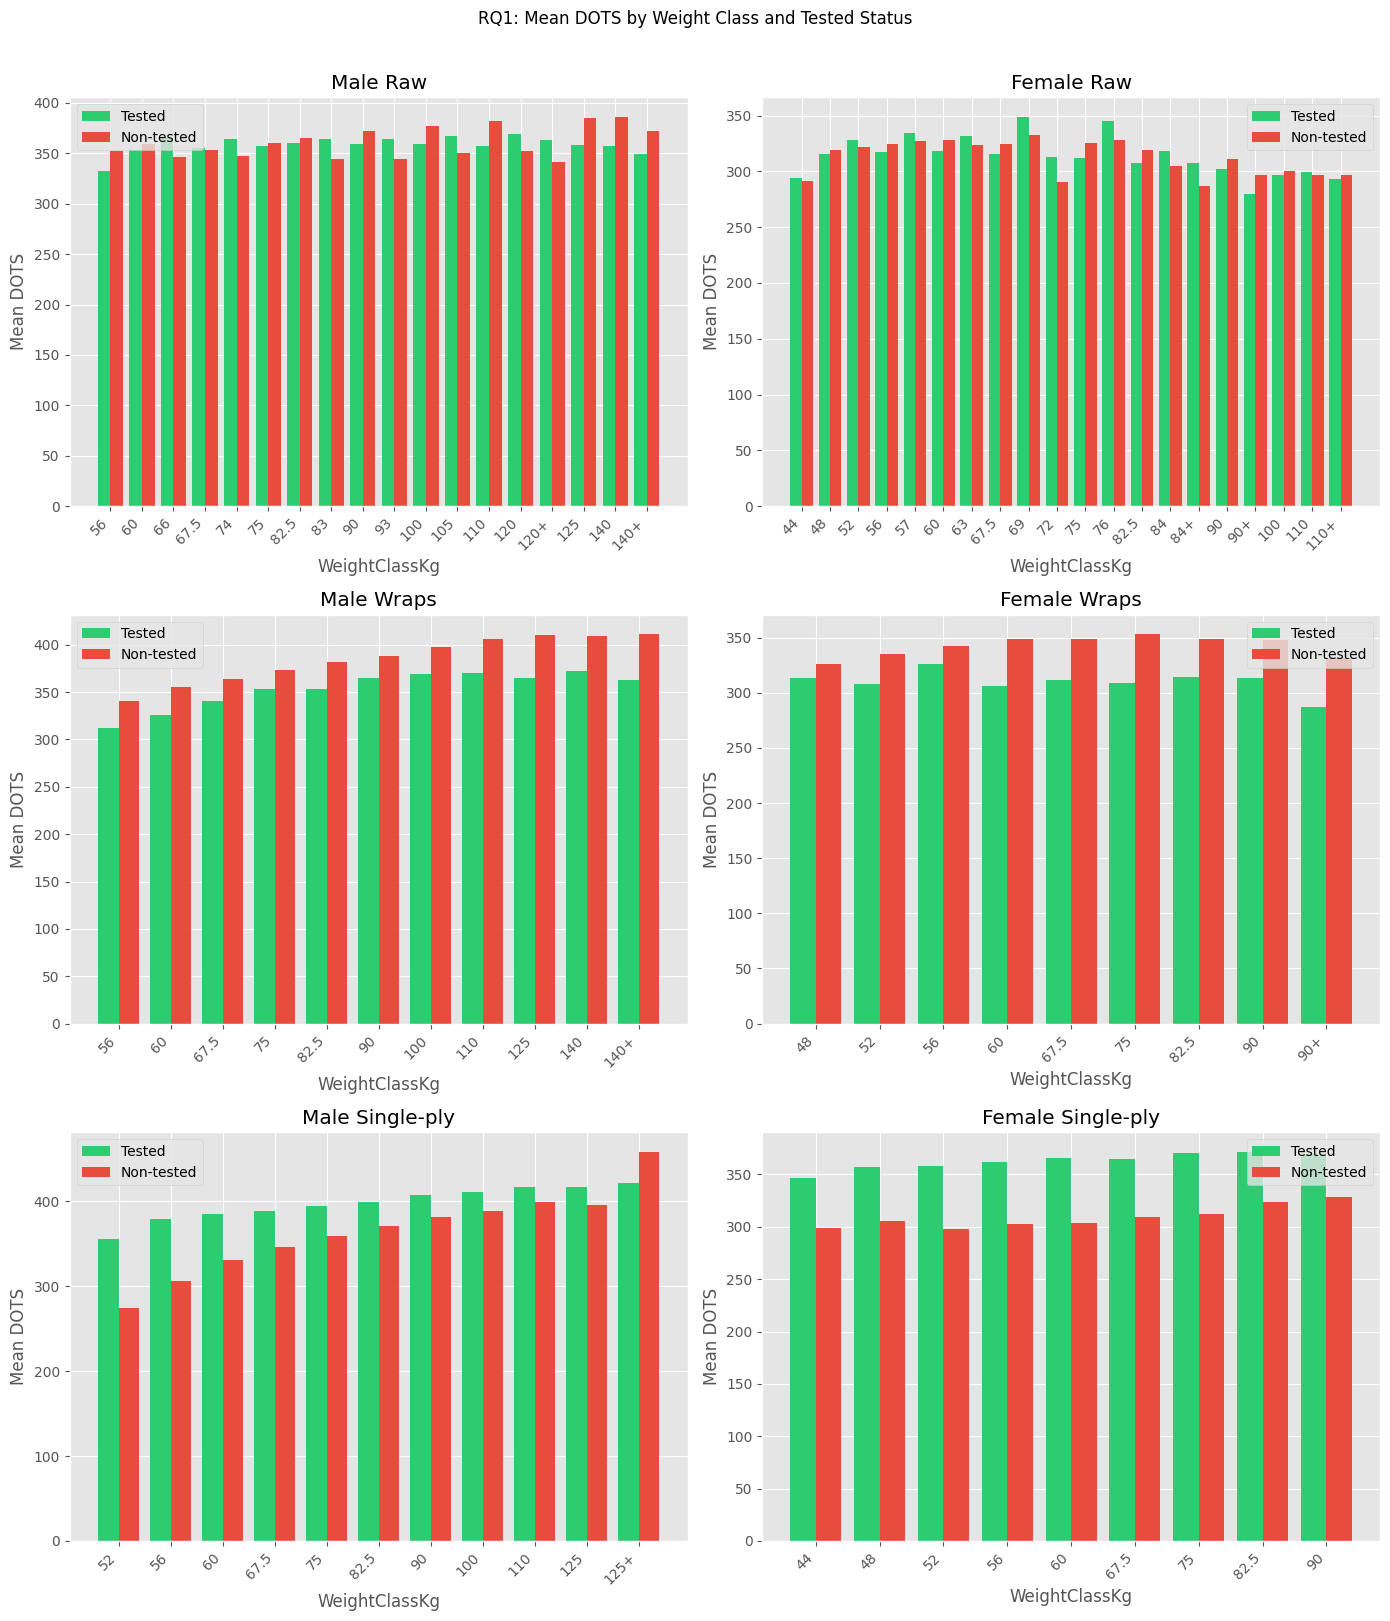

In [70]:
# =============================================================================
# RQ1 Mean DOTS by Weight Class (Bar Chart)
# Side-by-side bar chart comparing mean DOTS for tested vs. non-tested
# entries across weight classes, with separate panels for each
# Sex x Equipment combination (Raw, Wraps, Single-ply).
# =============================================================================

def weight_class_sort_key(wc_series):
    """Turn WeightClassKg into a numeric sort key.
    Strip the trailing '+' for the base number, then add 0.5 so that
    '125+' sorts after '125' instead of tying with it.
    """
    base = pd.to_numeric(
        wc_series.astype(str).str.replace("+", "", regex=False),
        errors="coerce"
    )
    is_plus = wc_series.astype(str).str.endswith("+")
    return base + is_plus * 0.5

summary = (
    rq1_supported_df
    .groupby(["Sex", "Equipment", "WeightClassKg", "is_tested"])
    .agg(mean_dots=("Dots", "mean"), n=("Dots", "size"))
    .reset_index()
)

equipment_order = ["Raw", "Wraps", "Single-ply"]

fig, axes = plt.subplots(len(equipment_order), 2, figsize=(14, 16))

for row_num, equip in enumerate(equipment_order):
    equip_df = summary[summary["Equipment"] == equip].copy()

    for col_num, sex in enumerate(["M", "F"]):
        ax = axes[row_num, col_num]
        sex_df = equip_df[equip_df["Sex"] == sex].copy()

        if len(sex_df) == 0:
            ax.set_title(f"{'Male' if sex == 'M' else 'Female'} {equip} (no data)")
            ax.set_xticks([])
            continue

        tested_df = sex_df[sex_df["is_tested"] == True].copy()
        untested_df = sex_df[sex_df["is_tested"] == False].copy()

        common_wcs = sorted(
            set(tested_df["WeightClassKg"]) & set(untested_df["WeightClassKg"])
        )
        tested_df = tested_df[tested_df["WeightClassKg"].isin(common_wcs)].copy()
        untested_df = untested_df[untested_df["WeightClassKg"].isin(common_wcs)].copy()

        tested_df["sort_key"] = weight_class_sort_key(tested_df["WeightClassKg"])
        untested_df["sort_key"] = weight_class_sort_key(untested_df["WeightClassKg"])

        tested_df = tested_df.sort_values("sort_key")
        untested_df = untested_df.sort_values("sort_key")

        x = np.arange(len(tested_df))

        ax.bar(x - 0.2, tested_df["mean_dots"], width=0.4, label="Tested", color="#2ecc71")
        ax.bar(x + 0.2, untested_df["mean_dots"], width=0.4, label="Non-tested", color="#e74c3c")
        ax.set_xticks(x)
        ax.set_xticklabels(tested_df["WeightClassKg"], rotation=45, ha="right")
        ax.set_xlabel("WeightClassKg")
        ax.set_ylabel("Mean DOTS")
        ax.set_title(f"{'Male' if sex == 'M' else 'Female'} {equip}")
        ax.legend()

plt.suptitle("RQ1: Mean DOTS by Weight Class and Tested Status", y=1.01)
plt.tight_layout()

# plt.savefig("figures/rq1_mean_dots_by_weightclass.svg", bbox_inches="tight")
plt.show()

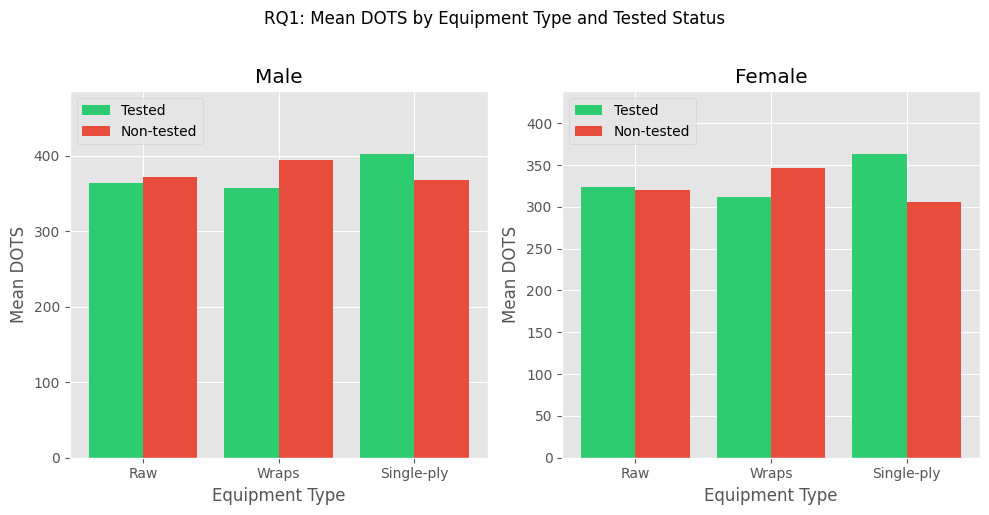

In [71]:
# =============================================================================
# RQ1 Mean DOTS by Equipment Type (Compact Report Chart)
# Side-by-side bar chart comparing mean DOTS for tested vs. non-tested
# entries across equipment types, with one panel per sex.
# This is a compact version of the weight-class chart above, intended
# for the written report where space is limited.
# =============================================================================

equip_summary = (
    rq1_supported_df
    .groupby(["Sex", "Equipment", "is_tested"])
    .agg(mean_dots=("Dots", "mean"))
    .reset_index()
)

equipment_order = ["Raw", "Wraps", "Single-ply"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for col_num, sex in enumerate(["M", "F"]):
    ax = axes[col_num]
    sex_df = equip_summary[equip_summary["Sex"] == sex].copy()

    tested_vals = []
    untested_vals = []
    for equip in equipment_order:
        t = sex_df[(sex_df["Equipment"] == equip) & (sex_df["is_tested"] == True)]
        u = sex_df[(sex_df["Equipment"] == equip) & (sex_df["is_tested"] == False)]
        tested_vals.append(t["mean_dots"].values[0] if len(t) > 0 else 0)
        untested_vals.append(u["mean_dots"].values[0] if len(u) > 0 else 0)

    x = np.arange(len(equipment_order))
    ax.bar(x - 0.2, tested_vals, width=0.4, label="Tested", color="#2ecc71")
    ax.bar(x + 0.2, untested_vals, width=0.4, label="Non-tested", color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(equipment_order)
    ax.set_xlabel("Equipment Type")
    ax.set_ylabel("Mean DOTS")
    ax.set_title(f"{'Male' if sex == 'M' else 'Female'}")

    # Add headroom so the legend does not overlap the bars
    y_lo, y_hi = ax.get_ylim()
    ax.set_ylim(y_lo, y_hi + (y_hi - y_lo) * 0.15)
    ax.legend(loc="upper left")

plt.suptitle("RQ1: Mean DOTS by Equipment Type and Tested Status", y=1.02)
plt.tight_layout()

# plt.savefig("figures/rq1_mean_dots_by_equipment.svg", bbox_inches="tight")
plt.show()

**Figure RQ1-1.** Mean DOTS score by weight class and tested status, shown separately for each equipment type (Raw, Wraps, Single-ply) and sex (Male, Female). Each row is one equipment type; the left column shows male lifters and the right column shows female lifters. Green bars represent tested entries; red bars represent non-tested entries.

### RQ1 Process Illustrations: Representative Subgroups

The tests above ran across all qualifying subgroups. The next eight figures zoom into two representative Male Raw subgroups to show what the process looks like on a single comparison. I picked both with a simple sample-size rule (the weight class with the most combined rows), not because they support or contradict the hypothesis.

- **Opposite-direction subgroup (Figures RQ1-2 through RQ1-5).** The largest Male Raw weight class overall, where tested athletes scored higher (the opposite direction from Ha).
- **Significant subgroup (Figures RQ1-6 through RQ1-9).** The largest Male Raw weight class among those where the permutation test came back significant.

The first four figures use the opposite-direction subgroup. The next four use the significant subgroup. For each subgroup I show four figures: a permutation null distribution and a bootstrap CI for both DOTS and TotalKg. The permutation plots overlay a KDE curve on the histogram to show the smooth shape of the null distribution. The bootstrap plots mark the observed gap, the 95% CI bounds, and zero.

Subgroup: Male / Raw / 93
Tested n = 12924, Non-tested n = 375
Observed gap (DOTS) = -19.59
Estimated permutation p-value = 1.0000
The estimated p-value is 1.0000, which is not less than 0.05.
We fail to reject the null hypothesis for this subgroup.


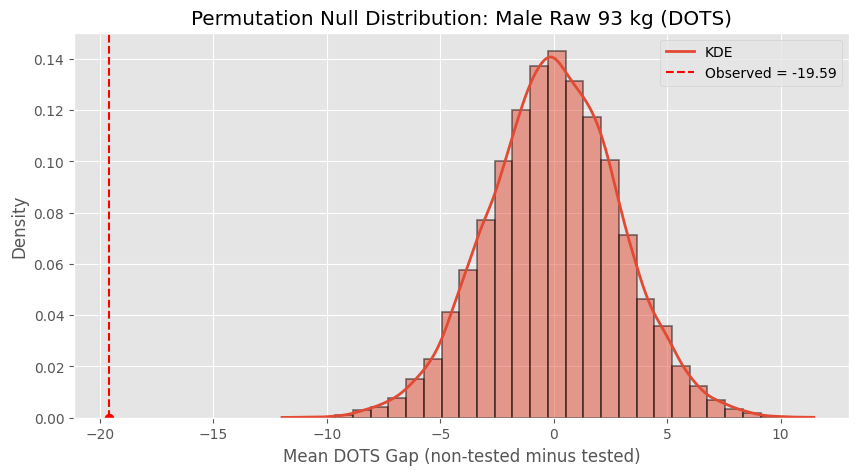

In [72]:
# =============================================================================
# RQ1 Permutation Null Distribution -- DOTS (Representative Subgroup)
# Shuffle tested/non-tested labels to build the null distribution of
# the mean DOTS gap for the largest Male Raw subgroup, then plot the
# histogram with KDE overlay and the observed gap.
# =============================================================================

# Filter to Male Raw subgroups, sum tested + non-tested counts to get
# the total sample size for each weight class, sort descending, and
# take the weight class with the most data so the illustration is stable.
demo_male_raw = rq1_results[
    (rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")
].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed test statistic
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says non-tested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_dots, tested_dots])
n_untested = len(untested_dots)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc} kg (DOTS)")
plt.xlabel("Mean DOTS Gap (non-tested minus tested)")
plt.ylabel("Density")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_dots)}, Non-tested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < ALPHA:
    print(f"The estimated p-value is less than {ALPHA}, so the gap is statistically significant.")
    print(f"We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than {ALPHA}.")
    print(f"We fail to reject the null hypothesis for this subgroup.")


plt.show()

**Figure RQ1-2.** Permutation null distribution for the mean DOTS gap in the largest (opposite-direction) Male Raw 93 kg subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/non-tested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 93
Tested n = 12924, Non-tested n = 375
Observed gap (DOTS) = -19.59
95% CI: [-24.76, -14.52]
The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.


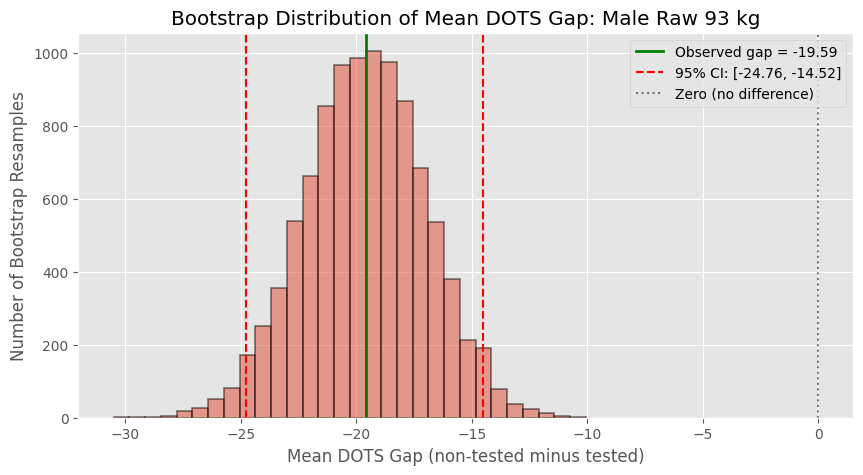

In [73]:
# =============================================================================
# RQ1 Bootstrap CI Illustration -- DOTS (Representative Subgroup)
# Bootstrap the mean DOTS gap for the largest Male Raw subgroup and
# plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Filter to Male Raw subgroups, sum tested + non-tested counts to get
# the total sample size for each weight class, sort descending, and
# take the weight class with the most data so the illustration is stable.
demo_male_raw = rq1_results[(rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed gap
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_dots, size=len(tested_dots), replace=True)
    boot_untested = np.random.choice(untested_dots, size=len(untested_dots), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean DOTS Gap: Male Raw {demo_wc} kg")
plt.xlabel("Mean DOTS Gap (non-tested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_dots)}, Non-tested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print(f"The 95% CI is entirely above zero, meaning non-tested lifters scored higher in this subgroup -- consistent with Ha.")
elif ci_high < 0:
    print(f"The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.")
else:
    print(f"The 95% CI includes zero, meaning the gap could be positive or negative -- not enough evidence to say which group scored higher in this subgroup.")


plt.show()

**Figure RQ1-3.** Bootstrap distribution of the mean DOTS gap (non-tested minus tested) for the largest (opposite-direction) Male Raw 93 kg subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

Subgroup: Male / Raw / 93
Tested n = 12924, Non-tested n = 375
Observed gap (TotalKg) = -33.99
Estimated permutation p-value = 1.0000
The estimated p-value is 1.0000, which is not less than 0.05.
We fail to reject the null hypothesis for this subgroup.


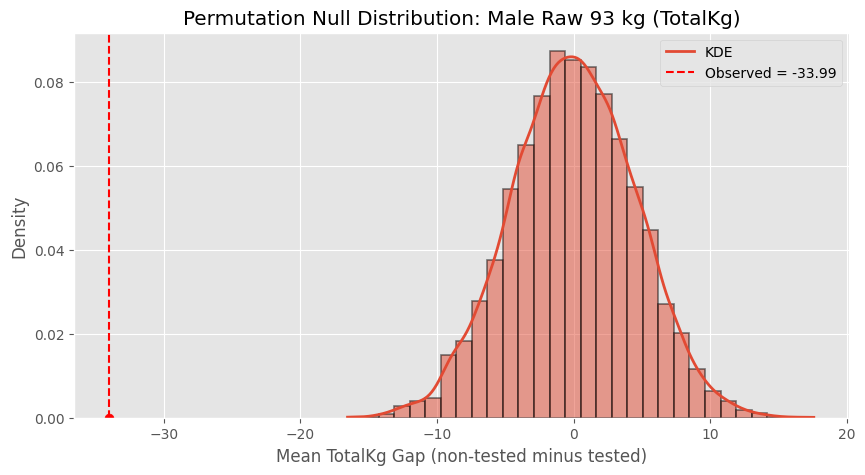

In [74]:
# =============================================================================
# RQ1 Permutation Null Distribution -- TotalKg (Representative Subgroup)
# Shuffle tested/non-tested labels to build the null distribution of
# the mean TotalKg gap for the same representative Male Raw subgroup,
# then plot the histogram with KDE overlay and the observed gap.
# =============================================================================

# Same representative subgroup as the DOTS illustration (Male Raw weight class with the most combined rows)
demo_male_raw = rq1_results[(rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed test statistic (non-tested minus tested)
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says non-tested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_total, tested_total])
n_untested = len(untested_total)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc} kg (TotalKg)")
plt.xlabel("Mean TotalKg Gap (non-tested minus tested)")
plt.ylabel("Density")
plt.legend()


print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_total)}, Non-tested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < ALPHA:
    print(f"The estimated p-value is less than {ALPHA}, so the gap is statistically significant.")
    print(f"We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than {ALPHA}.")
    print(f"We fail to reject the null hypothesis for this subgroup.")


plt.show()

**Figure RQ1-4.** Permutation null distribution for the mean TotalKg gap in the largest (opposite-direction) Male Raw 93 kg subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/non-tested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 93
Tested n = 12924, Non-tested n = 375
Observed gap (TotalKg) = -33.99
95% CI: [-42.00, -25.76]
The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.


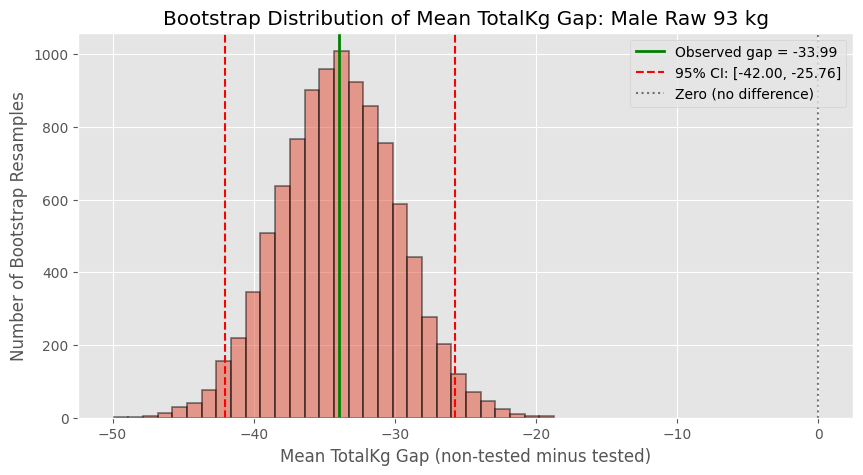

In [75]:
# =============================================================================
# RQ1 Bootstrap CI Illustration -- TotalKg (Representative Subgroup)
# Bootstrap the mean TotalKg gap for the same representative Male Raw
# subgroup and plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Same representative subgroup as the DOTS illustration
# (Male Raw weight class with the most combined rows)
demo_male_raw = rq1_results[(rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed gap
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_total, size=len(tested_total), replace=True)
    boot_untested = np.random.choice(untested_total, size=len(untested_total), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Plot the bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean TotalKg Gap: Male Raw {demo_wc} kg")
plt.xlabel("Mean TotalKg Gap (non-tested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_total)}, Non-tested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print(f"The 95% CI is entirely above zero, meaning non-tested lifters scored higher in this subgroup -- consistent with Ha.")
elif ci_high < 0:
    print(f"The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.")
else:
    print(f"The 95% CI includes zero, meaning the gap could be positive or negative -- not enough evidence to say which group scored higher in this subgroup.")


plt.show()

**Figure RQ1-5.** Bootstrap distribution of the mean TotalKg gap (non-tested minus tested) for the largest (opposite-direction) Male Raw 93 kg subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

Subgroup: Male / Raw / 100
Tested n = 2531, Non-tested n = 5388
Observed gap (DOTS) = 18.17
Estimated permutation p-value = 0.0000
The estimated p-value is less than 0.05, so the gap is statistically significant.
We reject the null hypothesis for this subgroup.


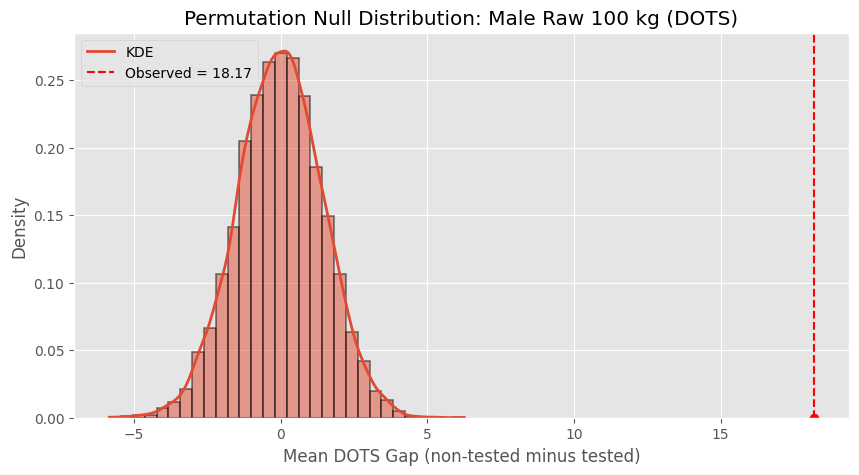

In [76]:
# =============================================================================
# RQ1 Permutation Null Distribution -- DOTS (Significant Subgroup)
# Shuffle tested/non-tested labels to build the null distribution of
# the mean DOTS gap for the significant Male Raw subgroup, then plot
# the histogram with KDE overlay and the observed gap.
# =============================================================================

# Filter to Male Raw subgroups where the permutation test was significant
# and non-tested lifters scored higher. Pick the weight class with the
# most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed test statistic
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says non-tested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_dots, tested_dots])
n_untested = len(untested_dots)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc_sig} kg (DOTS)")
plt.xlabel("Mean DOTS Gap (non-tested minus tested)")
plt.ylabel("Density")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_dots)}, Non-tested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < ALPHA:
    print(f"The estimated p-value is less than {ALPHA}, so the gap is statistically significant.")
    print(f"We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than {ALPHA}.")
    print(f"We fail to reject the null hypothesis for this subgroup.")


plt.show()

**Figure RQ1-6.** Permutation null distribution for the mean DOTS gap in the significant Male Raw 100 kg subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/non-tested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 100
Tested n = 2531, Non-tested n = 5388
Observed gap (DOTS) = 18.17
95% CI: [15.42, 20.96]
The 95% CI is entirely above zero, meaning non-tested lifters scored higher in this subgroup -- consistent with Ha.


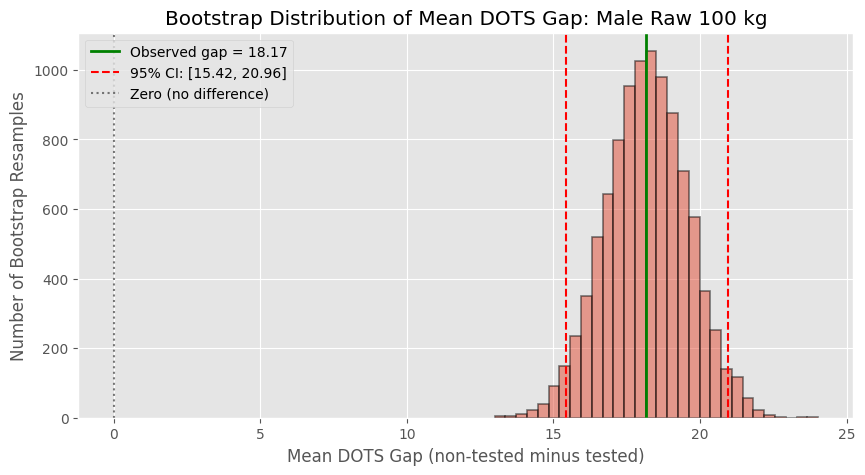

In [77]:
# =============================================================================
# RQ1 Bootstrap CI Illustration -- DOTS (Significant Subgroup)
# Bootstrap the mean DOTS gap for the significant Male Raw subgroup and
# plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Filter to Male Raw subgroups where the permutation test was significant
# and non-tested lifters scored higher. Pick the weight class with the
# most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed gap
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_dots, size=len(tested_dots), replace=True)
    boot_untested = np.random.choice(untested_dots, size=len(untested_dots), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean DOTS Gap: Male Raw {demo_wc_sig} kg")
plt.xlabel("Mean DOTS Gap (non-tested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_dots)}, Non-tested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print(f"The 95% CI is entirely above zero, meaning non-tested lifters scored higher in this subgroup -- consistent with Ha.")
elif ci_high < 0:
    print(f"The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.")
else:
    print(f"The 95% CI includes zero, meaning the gap could be positive or negative -- not enough evidence to say which group scored higher in this subgroup.")


plt.show()

**Figure RQ1-7.** Bootstrap distribution of the mean DOTS gap (non-tested minus tested) for the significant Male Raw 100 kg subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

Subgroup: Male / Raw / 100
Tested n = 2531, Non-tested n = 5388
Observed gap (TotalKg) = 29.29
Estimated permutation p-value = 0.0000
The estimated p-value is less than 0.05, so the gap is statistically significant.
We reject the null hypothesis for this subgroup.


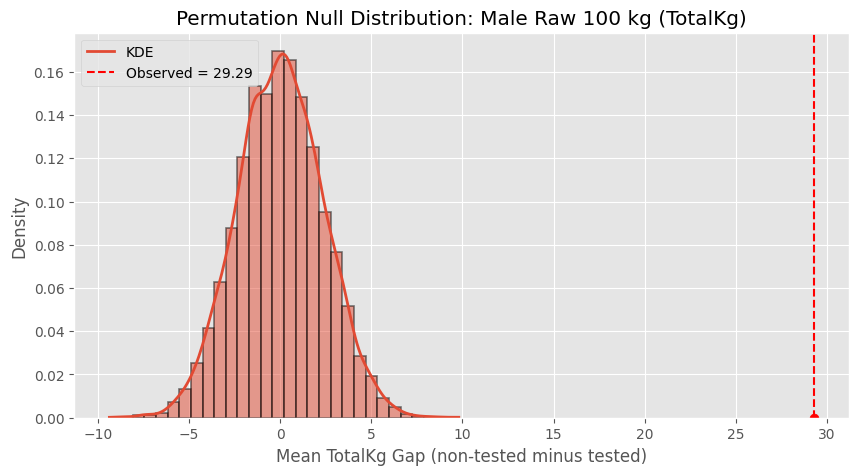

In [78]:
# =============================================================================
# RQ1 Permutation Null Distribution -- TotalKg (Significant Subgroup)
# Shuffle tested/non-tested labels to build the null distribution of
# the mean TotalKg gap for the significant Male Raw subgroup, then plot
# the histogram with KDE overlay and the observed gap.
# =============================================================================

# Same significant subgroup as the DOTS illustration
# Filter to Male Raw subgroups where the permutation test was significant
# and non-tested lifters scored higher. Pick the weight class with the
# most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed test statistic (non-tested minus tested)
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says non-tested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_total, tested_total])
n_untested = len(untested_total)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc_sig} kg (TotalKg)")
plt.xlabel("Mean TotalKg Gap (non-tested minus tested)")
plt.ylabel("Density")
plt.legend()


print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_total)}, Non-tested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < ALPHA:
    print(f"The estimated p-value is less than {ALPHA}, so the gap is statistically significant.")
    print(f"We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than {ALPHA}.")
    print(f"We fail to reject the null hypothesis for this subgroup.")


plt.show()

**Figure RQ1-8.** Permutation null distribution for the mean TotalKg gap in the significant Male Raw 100 kg subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/non-tested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 100
Tested n = 2531, Non-tested n = 5388
Observed gap (TotalKg) = 29.29
95% CI: [24.90, 33.73]
The 95% CI is entirely above zero, meaning non-tested lifters scored higher in this subgroup -- consistent with Ha.


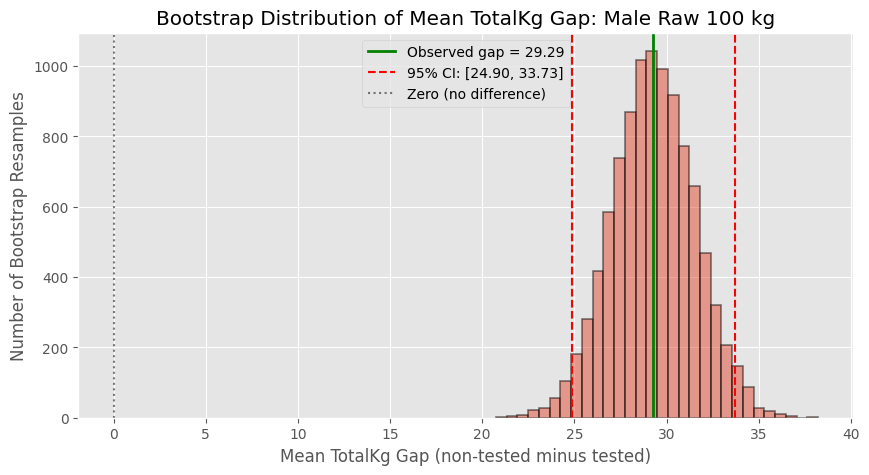

In [79]:
# =============================================================================
# RQ1 Bootstrap CI Illustration -- TotalKg (Significant Subgroup)
# Bootstrap the mean TotalKg gap for the significant Male Raw subgroup
# and plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Same significant subgroup as the DOTS illustration
# Filter to Male Raw subgroups where the permutation test was significant
# and non-tested lifters scored higher. Pick the weight class with the
# most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed gap
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_total, size=len(tested_total), replace=True)
    boot_untested = np.random.choice(untested_total, size=len(untested_total), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Plot the bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean TotalKg Gap: Male Raw {demo_wc_sig} kg")
plt.xlabel("Mean TotalKg Gap (non-tested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_total)}, Non-tested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print(f"The 95% CI is entirely above zero, meaning non-tested lifters scored higher in this subgroup -- consistent with Ha.")
elif ci_high < 0:
    print(f"The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.")
else:
    print(f"The 95% CI includes zero, meaning the gap could be positive or negative -- not enough evidence to say which group scored higher in this subgroup.")


plt.show()

**Figure RQ1-9.** Bootstrap distribution of the mean TotalKg gap (non-tested minus tested) for the significant Male Raw 100 kg subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

### RQ1 Conclusion  

**The data does not support a simple "non-tested entries always score higher" conclusion.**  

Across the 78 subgroups with enough data to test, the results were mixed. In 41 subgroups, non-tested entries scored higher on average; in the other 37, tested entries came out ahead. This same 41-to-37 split appeared for both TotalKg (the three-lift total) and DOTS (a bodyweight-adjusted strength score), which follows directly from the fact that both metrics ranked the subgroups in the same direction. In fact, every tally in the results summary came out the same for both metrics. Within a single weight class, bodyweight varies little, so the DOTS coefficient is nearly constant. That makes DOTS approximately proportional to TotalKg within each subgroup, which is why both metrics rank every subgroup the same way. That said, the size of the difference varied widely from one subgroup to the next.  
- Of the 78 subgroups, 35 showed a statistically significant difference favoring non-tested entries on both tests. However, testing that many subgroups increases the chance of false positives, so I treat these results as strong hints rather than definitive proof for any single subgroup. Because the analysis makes many subgroup comparisons, some apparently significant results may occur by chance alone.
- Whether non-tested or tested entries lifted more (direction of the gap) depended on equipment type, as Figure RQ1-1 suggests. In the Wraps category (knee wraps that aid the squat), non-tested entries tended to score higher. In Raw (minimal equipment), the results were mixed. In Single-ply (a single layer of supportive gear), tested entries more often came out ahead. Multi-ply was not discussed because none of its subgroups met the minimum-count rule.
- On the other side, 32 subgroups had 95% bootstrap CIs entirely below zero, meaning tested entries clearly outperformed non-tested entries in those matchups.

## RQ2: Testing, Testing... Anyone Still Here? (Trend Analysis)

**Is tested status associated with Dots-score bin, separately by sex?**

RQ2 uses one representative row per `Name x Sex x is_tested`, where repeated same-status entries are collapsed to a mean `Dots` value first. 

**Hypotheses:**  

- **H0:** `Dots`-score bin and drug-tested status are independent within each sex.
- **Ha:** `Dots`-score bin and drug-tested status are associated within each sex.

**Approach:**  

A chi-squared test of independence evaluates whether tested-entry proportions differ across Dots-score bins within each sex. The accompanying line chart illustrates the pattern the chi-squared test formally evaluates. Five equal-width bins were chosen as the most granular split that still keeps all expected cell frequencies above 5.

In [80]:
# =============================================================================
# RQ2 Bin Diagnostics and Chi-Squared Tests
# For each sex, bin the representative Dots values into 5 equal-width
# bins, build a contingency table crossing bin by tested status, and
# run a chi-squared test of independence.
# =============================================================================
for sex in ["M", "F"]:
    sex_df = rq2_analysis_df[rq2_analysis_df["Sex"] == sex].copy()

    # Split the Dots range into 5 equal-width bins for this sex.
    bin_edges = np.linspace(
        sex_df["Dots"].min(),
        sex_df["Dots"].max(),
        N_RQ2_BINS + 1
    )
    sex_df["dots_bin"] = pd.cut(
        sex_df["Dots"],
        bins=bin_edges,
        include_lowest=True
    )

    # Count rows in each (dots_bin, is_tested) group, then pivot so
    # each tested status becomes its own column. fill_value=0 means
    # any bin with no rows for a status gets a zero instead of NaN.
    contingency = (
        sex_df.groupby(["dots_bin", "is_tested"])
        .size()
        .unstack(fill_value=0)
    )

    # If a column is missing (e.g., no tested or no untested rows in a bin),
    # add it with zeros so both columns always exist.
    if True not in contingency.columns:
        contingency[True] = 0
    if False not in contingency.columns:
        contingency[False] = 0

    # Drop any bins that ended up completely empty (zero rows total).
    row_totals = contingency.sum(axis=1)
    contingency = contingency[row_totals > 0]

    # Run the chi-squared test of independence.
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    # Check whether every expected count is at least 5 (a requirement
    # for the chi-squared approximation to be valid).
    expected_ok = (expected >= 5).all()
    min_expected = expected.min()

    # Compute the tested-entry share (%) in each Dots bin.
    bin_totals = contingency.sum(axis=1)
    bin_tested = contingency[True]
    pct_tested = 100 * bin_tested / bin_totals

    sex_label = {"M": "Men", "F": "Women"}[sex]

    print("")
    
    print(f"Contingency table for {sex_label}:")
    display(contingency)

    print(f"Tested share by Dots bin for {sex_label} (%):")
    display(pct_tested.to_frame("% Tested"))

    print(f"\nChi-square test of independence for {sex_label}:") 
    print(f"\nchi2 = {chi2:.2f}, p = {p_val:.6f}, dof = {dof}")
    print(f"All expected counts >= 5: {expected_ok}")
    print(f"Minimum expected count: {min_expected:.2f}")

    print("")

    if p_val < ALPHA:
        print(f"p = {p_val:.6f} is less than {ALPHA}, so we reject H0.")
        print("")
        print(f"Testing rates are not uniform across strength levels.")
        print(f"We conclude that Dots-score bin and tested status are associated for {sex_label}.")
    else:
        print(f"p = {p_val:.6f} is not less than {ALPHA}, so we fail to reject H0.")
        print("")
        print(f"Testing rates appear uniform across strength levels")
        print(f"We conclude that there is no significant association between Dots-score bin and tested status for {sex_label}.")




Contingency table for Men:


is_tested,False,True
dots_bin,,
"(30.569, 168.729]",202,283
"(168.729, 306.888]",10497,14024
"(306.888, 445.048]",47083,68725
"(445.048, 583.207]",8809,14093
"(583.207, 721.366]",144,61


Tested share by Dots bin for Men (%):


,% Tested
dots_bin,
"(30.569, 168.729]",58.3505
"(168.729, 306.888]",57.1918
"(306.888, 445.048]",59.3439
"(445.048, 583.207]",61.5361
"(583.207, 721.366]",29.7561



Chi-square test of independence for Men:

chi2 = 166.99, p = 0.000000, dof = 4
All expected counts >= 5: True
Minimum expected count: 83.46

p = 0.000000 is less than 0.05, so we reject H0.

Testing rates are not uniform across strength levels.
We conclude that Dots-score bin and tested status are associated for Men.

Contingency table for Women:


is_tested,False,True
dots_bin,,
"(68.81899999999999, 205.988]",680,1447
"(205.988, 343.156]",13465,23575
"(343.156, 480.324]",5775,15340
"(480.324, 617.492]",429,922
"(617.492, 754.66]",17,7


Tested share by Dots bin for Women (%):


,% Tested
dots_bin,
"(68.81899999999999, 205.988]",68.0301
"(205.988, 343.156]",63.6474
"(343.156, 480.324]",72.6498
"(480.324, 617.492]",68.2457
"(617.492, 754.66]",29.1667



Chi-square test of independence for Women:

chi2 = 510.37, p = 0.000000, dof = 4
All expected counts >= 5: True
Minimum expected count: 7.93

p = 0.000000 is less than 0.05, so we reject H0.

Testing rates are not uniform across strength levels.
We conclude that Dots-score bin and tested status are associated for Women.


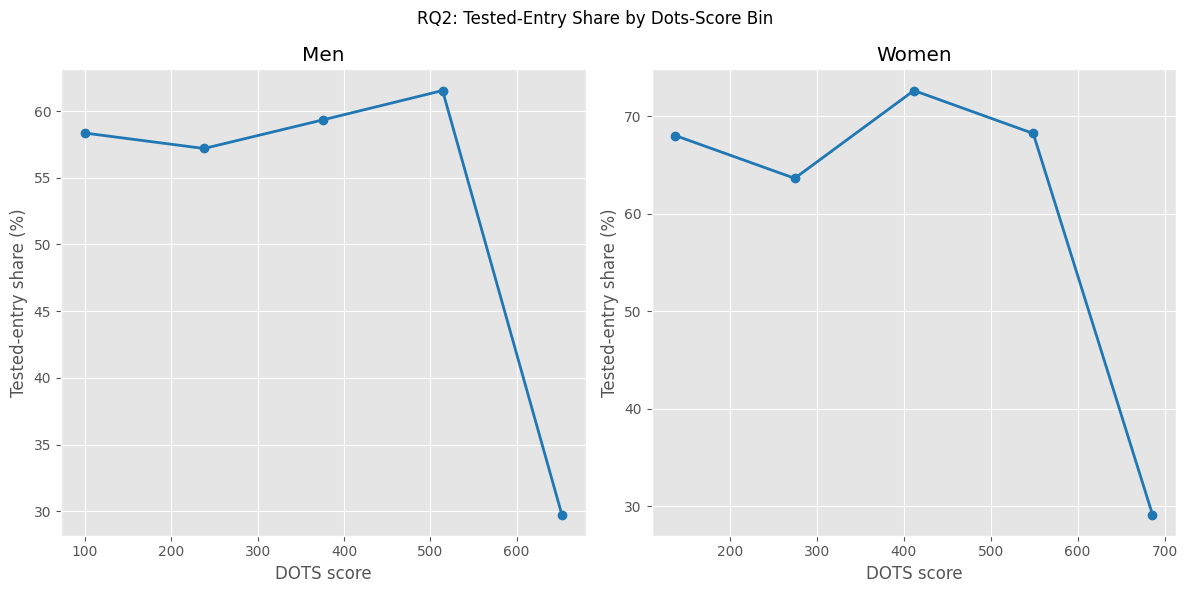

In [81]:
# =============================================================================
# RQ2 Tested-Entry Share by Dots-Score Bin (Line Chart)
# Plot the tested-entry share (%) across Dots bins for men and women
# in side-by-side panels so the trend is easy to see.
# =============================================================================
plt.figure(figsize=(12, 6))

for panel_num, sex in enumerate(["M", "F"], start=1):
    sex_df = rq2_analysis_df[rq2_analysis_df["Sex"] == sex].copy()

    # Same 5 equal-width Dots bins as the test cell above.
    bin_edges = np.linspace(
        sex_df["Dots"].min(),
        sex_df["Dots"].max(),
        N_RQ2_BINS + 1
    )
    sex_df["dots_bin"] = pd.cut(
        sex_df["Dots"],
        bins=bin_edges,
        include_lowest=True
    )

    # Count rows in each (dots_bin, is_tested) group, then pivot so
    # each tested status becomes its own column.
    contingency = (
        sex_df.groupby(["dots_bin", "is_tested"])
        .size()
        .unstack(fill_value=0)
    )
    # If a column is missing, add it with zeros so both columns always exist.
    if True not in contingency.columns:
        contingency[True] = 0
    if False not in contingency.columns:
        contingency[False] = 0
    row_totals = contingency.sum(axis=1)
    contingency = contingency[row_totals > 0]

    # Use the center of each bin as the x-axis position.
    midpoints = []
    for interval in contingency.index:
        midpoints.append((interval.left + interval.right) / 2)

    # Tested-entry share (%) in each bin.
    bin_totals = contingency.sum(axis=1)
    bin_tested = contingency[True]
    pct_tested = 100 * bin_tested / bin_totals

    # One panel per sex.
    plt.subplot(1, 2, panel_num)
    plt.plot(midpoints, pct_tested.values, marker="o", linewidth=2, color="#1f77b4")
    plt.xlabel("DOTS score")
    plt.ylabel("Tested-entry share (%)")
    plt.title("Men" if sex == "M" else "Women")

plt.suptitle("RQ2: Tested-Entry Share by Dots-Score Bin")
plt.tight_layout()

# plt.savefig("figures/rq2_tested_share_by_dots_bin.svg", bbox_inches="tight")
plt.show()

**Figure RQ2-1.** Tested-entry share (%) by Dots-score bin, shown separately for men (left) and women (right). Each point represents one of five equal-width Dots bins. The y-axis shows what percentage of representative rows in that bin came from tested competition entries.


### RQ2 Conclusion

**The share of drug-tested entries is not the same across all DOTS bins -- for either men or women.**

The chi-squared test of independence rejected H0 for both men (chi2 = 166.99, p < 0.001, dof = 4) and women (chi2 = 510.37, p < 0.001, dof = 4). The percentage of tested and non-tested entries shifts depending on how high the DOTS score is, and that shift is too large to be caused by random chance. All expected counts came in above 5 for both sexes, so the chi-squared approximation is on solid ground.

Looking at the trend in Figure RQ2-1:
- For men, the tested-entry share hovers in a fairly narrow band (~57-62%) across the first four bins, then drops sharply to about 30% in the highest-Dots bin.
- For women, the tested-entry share varies more across the first four bins (~64-73%) but shows a similar sharp drop to about 29% in the highest-Dots bin.
- In both cases, the top-performing bin is the only one where non-tested entries outnumber tested entries. That pattern is consistent with the idea that the very highest Dots scores show up disproportionately in non-tested competition contexts.


## RQ3: Age Is Just a Number... Or Is It? (Age Pattern Comparison)

**Among representative lifter-status rows with known age / assigned age bin, do non-tested rows tend to show higher mean `TotalKg` across age bins, and how does that gap look at different ages?**

RQ3 uses one representative row per `Name x Sex x age_bin x is_tested` among rows with known age / assigned age bin, where repeated same-status entries are collapsed to a mean `TotalKg` value first. OpenPowerlifting records approximate ages like `23.5` when the exact birthday is unknown; boundary values like these are kept in the lower bin (so `23.5` falls in `18-23`) for a consistent, reproducible grouping rule.

**Approach:**

First, a KDE overlay plot compares the representative-row `TotalKg` distributions for tested and non-tested groups in two representative age bins, giving a visual sense of how much the two groups overlap. Then a bootstrap interval summarizes the non-tested-minus-tested gap in mean representative-row `TotalKg` within each age bin and sex. Bootstrap intervals were used here because they do not assume the data follows any particular shape, and they still work when the groups being compared have different sizes or different amounts of spread.

Because the question is directional, the main interval-based check is the one-sided 95% lower bootstrap bound. When that lower bound is above zero, the data support higher mean representative-row `TotalKg` for non-tested rows in that bin. When the lower bound is at or below zero, the data do not give clear interval-based support for that direction. The accompanying line chart shows the age-bin patterns those bootstrap bounds summarize.


In [82]:
# =============================================================================
# RQ3 Summary Table
# For each Sex x age_bin x is_tested group, compute the count, mean
# representative-row TotalKg, and standard deviation so the tested and
# non-tested sides
# can be compared at a glance.
# =============================================================================
age_summary = (
    rq3_supported_df
    .groupby(["Sex", "age_bin", "is_tested"])
    .agg({"TotalKg": ["size", "mean", "std"]})
    .reset_index()
)

display(age_summary.sort_values(["Sex", "age_bin", "is_tested"]))


Sex age_bin is_tested TotalKg                  
                            size     mean      std
0    F   18-23     False    1968 315.9559  69.9667
1    F   18-23      True   11045 317.1978  79.7194
2    F   24-30     False    7534 318.3481  72.9088
3    F   24-30      True   14265 326.0673  77.0700
4    F   31-40     False    4904 326.6819  82.8560
5    F   31-40      True    8508 324.9050  78.5166
6    F   41-50     False    1048 339.5328  93.9541
7    F   41-50      True    2170 319.1038  77.1214
8    F   51-60     False     289 313.6105  95.1486
9    F   51-60      True     662 287.9813  66.5011
10   F     61+     False      84 264.5077  78.0779
11   F     61+      True     181 250.1724  65.0282
12   M   18-23     False    6497 582.3539 124.7566
13   M   18-23      True   29890 564.7160 119.3762
14   M   24-30     False   18599 607.9908 128.8282
15   M   24-30      True   32031 597.2655 120.6896
16   M   31-40     False   11091 628.7909 136.0901
17   M   31-40      True   17140 605.0551 126.1582
18   M   41-50     False    1903 627.6857 132.8051
19   M   41-50      True    4009 584.1671 125.5581
20   M   51-60     False     510 552.5706 126.4462
21   M   51-60      True    1367 512.2113 114.9997
22   M     61+     False     147 439.8328 117.3554
23   M     61+      True     507 412.4606 103.3724

The summary table above shows the average representative-row TotalKg and its spread for each group. 

Before interpreting the bootstrap interval results, I wanted to look at the overall shape of the representative-row TotalKg distributions in a couple of representative age bins, and chose 24-30 and 41-50. These two bins were chosen because the 24-30 bin has the most representative rows and shows a small or reversed gap, while the 41-50 bin shows the largest gap for men and a clear separation for women. For women, the largest gap is actually in 51-60, but 41-50 still gives a strong middle-age contrast with more representative rows behind it. Together they let us see what heavy overlap looks like versus a clear shift between tested and non-tested curves.

The KDE curves below estimate a smooth density directly from the representative-row TotalKg values using Gaussian kernels with Silverman's rule bandwidth. The histograms are shown as a visual reference, and each panel overlays the tested (green) and non-tested (red) distributions so the two can be compared directly.


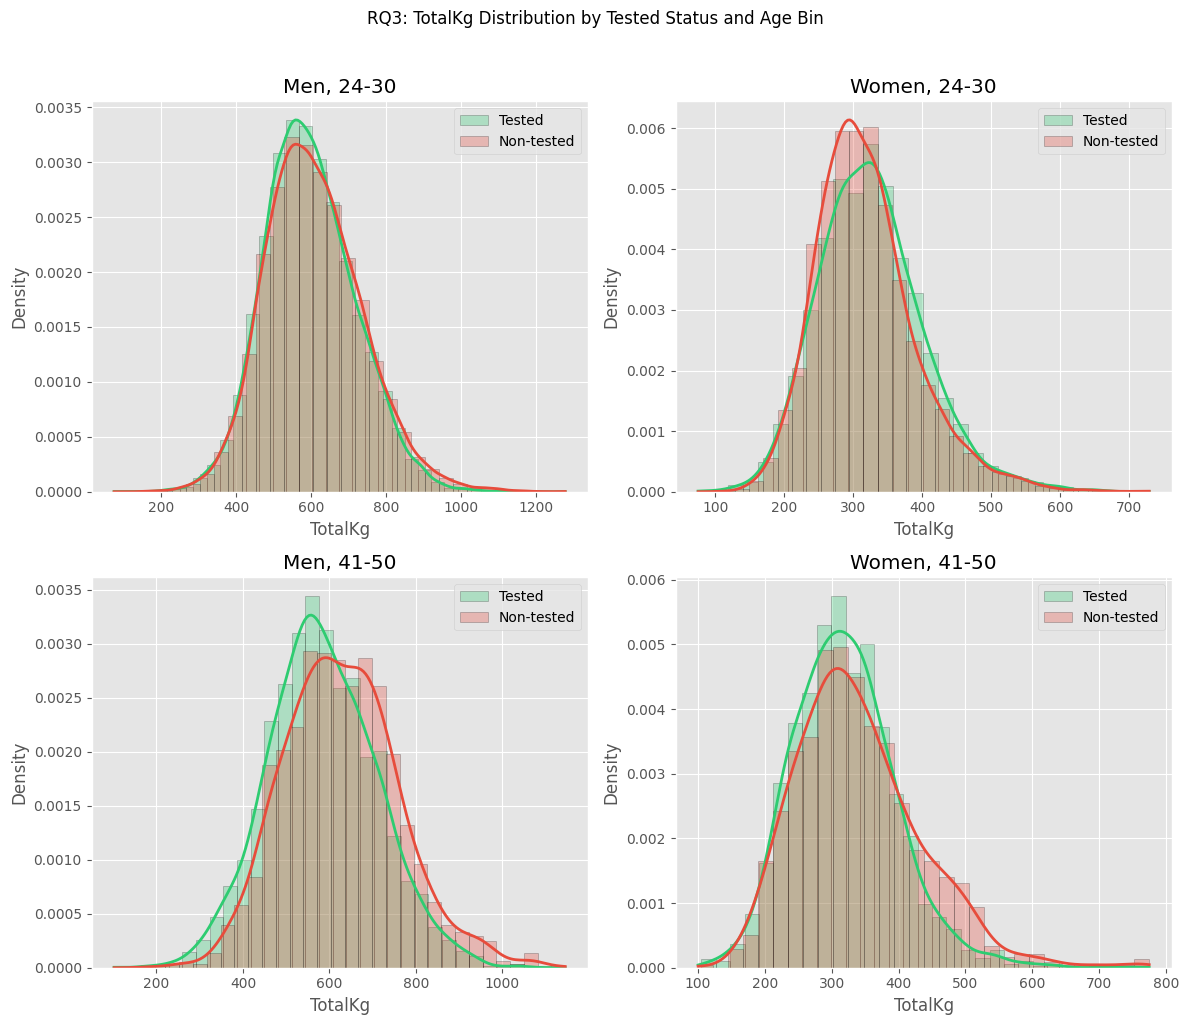

In [83]:
# =============================================================================
# RQ3 TotalKg Distributions by Tested Status (KDE)
# For two representative age bins (24-30 and 41-50), plot the
# representative-row TotalKg distribution for tested and non-tested
# groups side by side for men and women. 
# Each panel overlays a histogram with a KDE curve fit
# using Silverman's rule bandwidth.
# =============================================================================
DEMO_AGE_BINS = ["24-30", "41-50"]

plt.figure(figsize=(12, 10))

panel_num = 0
for age_label in DEMO_AGE_BINS:
    for sex in ["M", "F"]:
        panel_num += 1
        plt.subplot(2, 2, panel_num)

        # Filter to this sex and age bin
        age_df = rq3_supported_df[
            (rq3_supported_df["Sex"] == sex) &
            (rq3_supported_df["age_bin"] == age_label)
        ]

        tested_vals = age_df[age_df["is_tested"] == True]["TotalKg"].values
        untested_vals = age_df[age_df["is_tested"] == False]["TotalKg"].values

        # Shared evaluation grid so both curves use the same x-axis
        all_vals = np.concatenate([tested_vals, untested_vals])
        x_values = np.linspace(all_vals.min(), all_vals.max(), 200)

        # KDE with Silverman's rule bandwidth
        kde_tested = gaussian_kde(tested_vals, bw_method="silverman")
        kde_untested = gaussian_kde(untested_vals, bw_method="silverman")

        # Histograms (normalized to density so they match the KDE scale)
        plt.hist(tested_vals, bins=30, density=True, alpha=0.3,
                 edgecolor="black", linewidth=0.5,
                 color="#2ecc71", label="Tested")
        plt.hist(untested_vals, bins=30, density=True, alpha=0.3,
                 edgecolor="black", linewidth=0.5,
                 color="#e74c3c", label="Non-tested")

        # KDE overlay curves
        plt.plot(x_values, kde_tested.evaluate(x_values),
                 color="#2ecc71", linewidth=2)
        plt.plot(x_values, kde_untested.evaluate(x_values),
                 color="#e74c3c", linewidth=2)

        sex_label = "Men" if sex == "M" else "Women"
        plt.title(f"{sex_label}, {age_label}")
        plt.xlabel("TotalKg")
        plt.ylabel("Density")
        plt.legend()

plt.suptitle("RQ3: TotalKg Distribution by Tested Status and Age Bin", y=1.02)
plt.tight_layout()
# plt.savefig("figures/rq3_totalkg_kde_by_age_bin.svg", bbox_inches="tight")
plt.show()

**Figure RQ3-1.** The height of each curve shows how common a representative-row `TotalKg` value is within that group. Where the two curves sit on top of each other, tested and non-tested representative rows posted similar totals; where one curve sits to the right, that side tended to have higher representative-row totals.

In [84]:
# =============================================================================
# RQ3 Bootstrap Gap Bounds and Interval Evidence
# For each Sex x age_bin pair, bootstrap the gap (non-tested mean minus tested mean)
# in representative-row TotalKg. The main directional check is the one-sided 95% lower
# bootstrap bound, and the 95th percentile is kept for the plotted whiskers.
# =============================================================================
rq3_results = []

for sex in ["M", "F"]:
    sex_df = rq3_supported_df[rq3_supported_df["Sex"] == sex].copy()

    for age_label in AGE_LABELS:
        age_df = sex_df[sex_df["age_bin"] == age_label]

        tested_vals = age_df[age_df["is_tested"] == True]["TotalKg"].dropna().values
        untested_vals = age_df[age_df["is_tested"] == False]["TotalKg"].dropna().values

        if min(len(tested_vals), len(untested_vals)) < MIN_COUNT:
            rq3_results.append({
                "Sex": sex,
                "age_bin": age_label,
                "n_tested": len(tested_vals),
                "n_untested": len(untested_vals),
                "gap_total": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "note": "below MIN_COUNT"
            })
            continue

        observed_gap = np.mean(untested_vals) - np.mean(tested_vals)

        boot_gaps = []
        for i in range(N_BOOTSTRAP):
            boot_tested = np.random.choice(tested_vals, size=len(tested_vals), replace=True)
            boot_untested = np.random.choice(untested_vals, size=len(untested_vals), replace=True)
            boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

        boot_gaps = np.array(boot_gaps)
        ci_low, ci_high = np.percentile(boot_gaps, [5, 95])

        rq3_results.append({
            "Sex": sex,
            "age_bin": age_label,
            "n_tested": len(tested_vals),
            "n_untested": len(untested_vals),
            "gap_total": observed_gap,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "note": ""
        })

rq3_results = pd.DataFrame(rq3_results)
display(rq3_results)

# Interval evidence summary for each age bin
print("")
print("=" * 65)
print("RQ3 Interval Evidence (one-sided 95% lower bootstrap bound)")
print("A positive gap means non-tested minus tested is above zero.")
print("When the lower bound is above zero, that bin supports")
print("    higher mean representative-row TotalKg for non-tested rows.")
print("=" * 65)
print("")

support_count = 0
total_count = 0

for sex in ["M", "F"]:
    sex_label = "Men" if sex == "M" else "Women"
    sex_rows = rq3_results[rq3_results["Sex"] == sex]
    print(f"\n--- {sex_label} ---")

    for _, row in sex_rows.iterrows():
        if pd.isna(row["gap_total"]):
            continue

        total_count += 1
        age_bin = row["age_bin"]
        gap = row["gap_total"]
        ci_lo = row["ci_low"]
        ci_hi = row["ci_high"]

        print(f"\n  {age_bin}: gap = {gap:.2f}, bootstrap range [{ci_lo:.2f}, {ci_hi:.2f}]")

        if ci_lo > 0:
            support_count += 1
            print(f"    The one-sided 95% lower bootstrap bound is above zero.")
            print(f"    This bin supports higher mean representative-row TotalKg for non-tested rows.")
        elif ci_hi < 0:
            print(f"    The displayed bootstrap range stays below zero.")
            print(f"    In this bin, tested representative rows averaged higher in the sample.")
        else:
            print(f"    The one-sided 95% lower bootstrap bound is not above zero.")
            print(f"    This bin does not provide clear interval-based support for the non-tested-higher direction.")

print("")
print("=" * 65)

m_rows = rq3_results[rq3_results["Sex"] == "M"]
f_rows = rq3_results[rq3_results["Sex"] == "F"]
m_support = (m_rows["ci_low"] > 0).sum()
f_support = (f_rows["ci_low"] > 0).sum()
m_total = m_rows["gap_total"].notna().sum()
f_total = f_rows["gap_total"].notna().sum()

print(f"Summary: {support_count} of {total_count} age bins have a one-sided 95% lower bound above zero.")
print(f"  Men:   {m_support} of {m_total} bins show interval-based support.")
print(f"  Women: {f_support} of {f_total} bins show interval-based support.")

print("=" * 65)
print("")


,Sex,age_bin,n_tested,n_untested,gap_total,ci_low,ci_high,note
0,M,18-23,29890,6497,17.6378,14.8644,20.4604,
1,M,24-30,32031,18599,10.7254,8.7835,12.6379,
2,M,31-40,17140,11091,23.7359,21.1124,26.3950,
3,M,41-50,4009,1903,43.5187,37.4994,49.5579,
4,M,51-60,1367,510,40.3593,29.8470,50.8408,
5,M,61+,507,147,27.3722,9.4108,45.0521,
6,F,18-23,11045,1968,-1.2419,-4.1656,1.6416,
7,F,24-30,14265,7534,-7.7193,-9.4767,-5.9913,
8,F,31-40,8508,4904,1.7769,-0.6165,4.1053,
9,F,41-50,2170,1048,20.4291,15.0286,25.9106,



RQ3 Interval Evidence (one-sided 95% lower bootstrap bound)
A positive gap means non-tested minus tested is above zero.
When the lower bound is above zero, that bin supports
    higher mean representative-row TotalKg for non-tested rows.


--- Men ---

  18-23: gap = 17.64, bootstrap range [14.86, 20.46]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg for non-tested rows.

  24-30: gap = 10.73, bootstrap range [8.78, 12.64]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg for non-tested rows.

  31-40: gap = 23.74, bootstrap range [21.11, 26.39]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg for non-tested rows.

  41-50: gap = 43.52, bootstrap range [37.50, 49.56]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-r

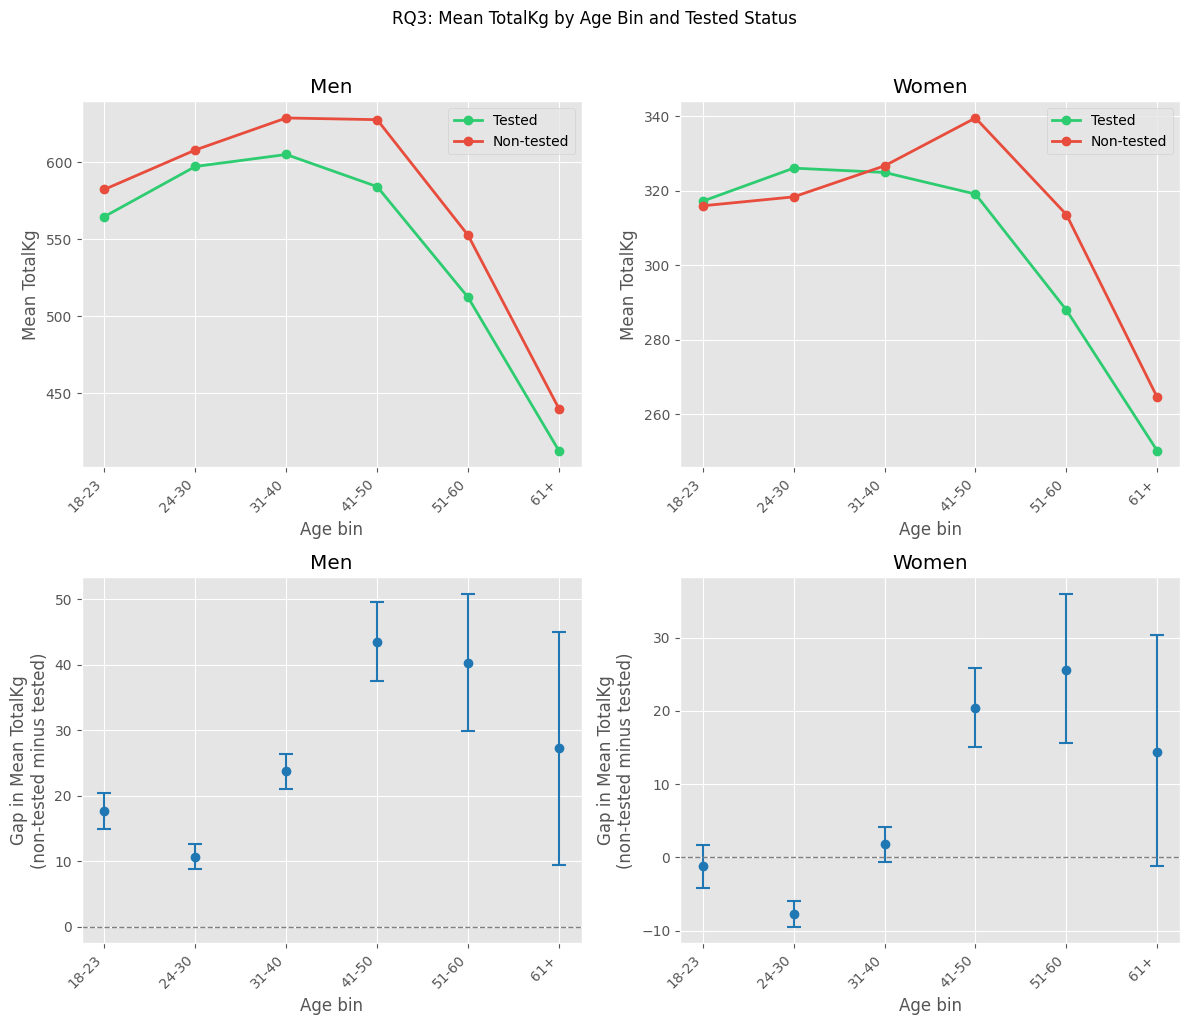

In [85]:
# =============================================================================
# RQ3 Mean TotalKg by Age Bin
# Top row: line chart comparing mean representative-row TotalKg for
# tested vs. non-tested groups across age bins, with separate panels
# for men and women.
# Bottom row: the gap (non-tested minus tested) with the one-sided 95%
# lower bootstrap bound as the lower whisker and the 95th percentile
# as the upper whisker for visual context.
# =============================================================================
age_summary = (
    rq3_supported_df
    .groupby(["Sex", "age_bin", "is_tested"])
    .agg(mean_total=("TotalKg", "mean"))
    .reset_index()
)

plt.figure(figsize=(12, 10))

panel_num = 0

for sex in ["M", "F"]:
    sex_summary = age_summary[age_summary["Sex"] == sex].copy()

    tested_line = sex_summary[sex_summary["is_tested"] == True].copy()
    untested_line = sex_summary[sex_summary["is_tested"] == False].copy()

    tested_line = tested_line.sort_values("age_bin")
    untested_line = untested_line.sort_values("age_bin")

    x = np.arange(len(AGE_LABELS))

    tested_y = []
    untested_y = []
    for age_label in AGE_LABELS:
        tested_match = tested_line[tested_line["age_bin"] == age_label]["mean_total"]
        untested_match = untested_line[untested_line["age_bin"] == age_label]["mean_total"]

        tested_y.append(tested_match.iloc[0] if len(tested_match) > 0 else np.nan)
        untested_y.append(untested_match.iloc[0] if len(untested_match) > 0 else np.nan)

    # ---- Top row: mean TotalKg lines ----
    panel_num += 1
    plt.subplot(2, 2, panel_num)
    plt.plot(x, tested_y, marker="o", linewidth=2, label="Tested", color="#2ecc71")
    plt.plot(x, untested_y, marker="o", linewidth=2, label="Non-tested", color="#e74c3c")
    plt.xticks(x, AGE_LABELS, rotation=45, ha="right")
    plt.xlabel("Age bin")
    plt.ylabel("Mean TotalKg")
    plt.title("Men" if sex == "M" else "Women")
    plt.legend()

for sex in ["M", "F"]:
    sex_results = rq3_results[rq3_results["Sex"] == sex].copy()

    x = np.arange(len(AGE_LABELS))

    gap_y = []
    ci_lo_list = []
    ci_hi_list = []
    for age_label in AGE_LABELS:
        row = sex_results[sex_results["age_bin"] == age_label]
        if len(row) > 0 and pd.notna(row.iloc[0]["gap_total"]):
            gap_y.append(row.iloc[0]["gap_total"])
            ci_lo_list.append(row.iloc[0]["ci_low"])
            ci_hi_list.append(row.iloc[0]["ci_high"])
        else:
            gap_y.append(np.nan)
            ci_lo_list.append(np.nan)
            ci_hi_list.append(np.nan)

    gap_y = np.array(gap_y)
    ci_lo_arr = np.array(ci_lo_list)
    ci_hi_arr = np.array(ci_hi_list)

    # Error bars: distance from the gap to each CI bound
    yerr_low = gap_y - ci_lo_arr
    yerr_high = ci_hi_arr - gap_y

    # ---- Bottom row: gap with CI whiskers ----
    panel_num += 1
    plt.subplot(2, 2, panel_num)
    plt.errorbar(x, gap_y, yerr=[yerr_low, yerr_high],
                 fmt="o", capsize=5, linewidth=2, color="#1f77b4",
                 ecolor="#1f77b4", elinewidth=1.5, capthick=1.5)
    plt.axhline(0, linestyle="--", color="gray", linewidth=1)
    plt.xticks(x, AGE_LABELS, rotation=45, ha="right")
    plt.xlabel("Age bin")
    plt.ylabel("Gap in Mean TotalKg\n(non-tested minus tested)")
    plt.title("Men" if sex == "M" else "Women")

plt.suptitle("RQ3: Mean TotalKg by Age Bin and Tested Status", y=1.02)
plt.tight_layout()
# plt.savefig("figures/rq3_mean_totalkg_by_age_bin.svg", bbox_inches="tight")
plt.show()

**Figure RQ3-2.** Mean representative-row TotalKg by age bin and tested status, shown separately for men (left) and women (right). The top row plots the mean representative-row TotalKg for tested (green) and non-tested (red) rows in each of six age bins. The bottom row shows the gap (non-tested mean minus tested mean) in representative-row TotalKg for each bin. The lower whisker marks the one-sided 95% lower bootstrap bound used for the interval evidence check, and the upper whisker shows the matching 95th percentile for visual context. The dashed gray line at zero marks the point of no difference.

### RQ3 Conclusion  

**Among representative rows with known age / assigned age bin, non-tested rows tended to post higher mean `TotalKg` than tested rows for men at every age bin. For women, the picture stayed mixed: younger bins showed little separation or tilted toward tested rows, while the clearest non-tested advantage appeared in middle age.**

The interval evidence supports the non-tested-higher direction in 8 of 12 age bins. For men, all six bins had a one-sided 95% lower bootstrap bound above zero, so every male age bin supported higher mean `TotalKg` for non-tested representative rows. For women, only 2 of 6 bins (41-50 and 51-60) showed that same pattern. In the 24-30 bin, the displayed bootstrap range stayed entirely below zero, meaning tested representative rows averaged higher than non-tested representative rows in that age range.

The representative-row distribution shapes in Figure RQ3-1 match that pattern. In the 41-50 bin the non-tested curve sits clearly to the right for both sexes. In the 24-30 bin the curves overlap almost completely for men, and for women the tested curve edges ahead.

Figure RQ3-2 shows how the representative-row gap changes with age:
- For men, the gap is moderate at 18-23 (~18 kg), dips at 24-30, then widens through middle age, peaking around 41-50 (~44 kg).
- For women, the gap hovers near zero through the 30s, then flips and grows at 41-50 (~20 kg) and 51-60 (~26 kg). The 61+ bin trends the same way (~14 kg) but the lower bound is not above zero.
- In both sexes, whatever drives the tested/non-tested split is most visible in middle and older age groups.
